# STATS502 — Final Project

# TalentLens Analytics: Building an Intelligent Job Intelligence Platform

**Group members (fill in before submitting):**

GROUP ID: 10

- Student 1: Emmanuelle Nsingui-Nsavuka — 000638287
- Student 2: Lucas Mazagão — 000642731
- Student 3: Joël Massicot — 000642885

**Submission date:** Sunday 17th May 2026 at 11.59pm

**How to submit**: Run all cells (Runtime → Run all), then download the executed notebook (File → Download → Download .ipynb) and send the notebook by email to the teaching assistant. **The notebook must contain all outputs — empty outputs cannot be graded.**

⚠️ Typical error from students:
**The notebook doesn't contain any output.**

⚠️ Typical error from students:
**When you download the notebook, you have to download it as .ipynb, not as .py**

---

# The Mission

**TalentLens Analytics** is an HR-tech startup building an AI-powered job intelligence platform. They have acquired a large dataset of LinkedIn job postings and hired your team to:

1. **Build a seniority classifier** — automatically tag job postings that don't declare their level
2. **Segment the job market** — discover natural role clusters to power a *'Jobs like this one'* feature
3. **Build a semantic search engine** — let users search in plain language and get relevant results

This project covers every major technique from this semester: supervised learning, unsupervised learning, NLP, and LLMs — combined in a single end-to-end pipeline.

---
# Grading Rubric

My two main goals are:
1. To see that you can re-use the notebooks from the practical sessions, the references I give you in this project, etc. to answer the questions.
2. To be sure you understood what you coded.


## 1. Submission Requirements

- Your submitted file must be a `.ipynb` notebook — not a `.py` file or any other format.
- Your notebook must contain **all outputs** from all executed code cells. Do not clear outputs before submitting.
- Your notebook must **run from top to bottom without errors** on a clean kernel. If I cannot reproduce your results by running all cells in order, your submission may not be graded.
- Submit only **one file**. If you send multiple versions, only the last one received before the deadline will be graded.

> <font color='red'>⚠️ **It is considered a late submission if you send a notebook without any code outputs, or you send a `.py` file rather than a `.ipynb` file, and I have to ask you for the proper deliverable.**</font>


## 2. Notebook Quality

You will get penalties if:

- Your notebook is messy and/or contains empty code cells, dead code, or cells that don't answer any question. Your final notebook should be clean and straightforward.
- Your code lacks proper inline comments explaining the logic. A reader should understand *why* you wrote what you wrote, not just *what* it does.
- Variable and function names are not meaningful (e.g. `x`, `df2`, `temp` used throughout).
- A plot is missing a title, axis labels, or a legend where one is needed.


## 3. Answer Quality

You will get penalties if:

- A question is left unanswered.
- Your answer is generic and not anchored to your specific results and to the dataset you used. I expect you to interpret *your* numbers, not describe the method in the abstract.
- Your answer covers more than what the question asks, without explicitly explaining why. If your answer goes beyond the scope of the question, add a short comment justifying it — otherwise it suggests you didn't identify what was actually asked.
- You describe what your code does without explaining what the results *mean* in the context of the dataset.


## 4. GenAI & Academic Integrity Rules

- **GenAI tools are recommended** — use them to help you understand concepts, debug code, and structure your answers.
- However, <font color='red'>**copy-pasting from GenAI is considered plagiarism and is strictly forbidden**</font>. Any answer that is not clearly anchored to the question, your specific results, and your dataset will be treated as GenAI copy-paste and will result in a <font color='red'>**grade of 0 for the entire project**</font>.
- You are individually responsible for everything in your notebook. You must be able to explain every line of code and every written answer. GenAI is a tool, not a co-author.
- Copying another student's work — in whole or in part — is strictly forbidden and will result in a zero for all parties involved, regardless of who copied from whom.
- External code copied from online sources (Stack Overflow, GitHub, etc.) must be cited with a comment indicating the source URL.


## 5. Late Submission

The deadline is <font color='red'>**Sunday 17th May 2026 at 11:59pm**</font>.

- You will lose **20% of your grade** if I receive your work between Monday 18th May 2026 at 12:00am and 6:00am.
- Submissions received **after 6:00am on Monday 18th May 2026** will **not be graded**, to be fair to all students.

> <font color='red'>⚠️ **It is considered a late submission if you send a notebook without any code outputs, or you send a `.py` file rather than a `.ipynb` file, and I have to ask you for the proper deliverable.**</font>

---

---
# Part 0 — Setup & Data Exploration
## ✅ This part is fully provided — read it, run it, understand it.

In [58]:
# Install required libraries (run once — restart runtime if prompted)
!pip install -q sentence-transformers transformers accelerate bitsandbytes
!pip install --upgrade transformers

In [59]:
# ─── Standard imports ───
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, re, warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# NLP & LLM
from sentence_transformers import SentenceTransformer
import transformers
transformers.logging.set_verbosity_error()
from transformers import pipeline
import torch

np.random.seed(42)
print('All libraries loaded successfully!')
print(f"GPU available: {'YES ✅' if torch.cuda.is_available() else 'NO ⚠️ — enable GPU for Part 3.3: Runtime → Change runtime type → T4 GPU. In French: Exécution → Modifier le type d\'exécution → GPU T4.'}")

All libraries loaded successfully!
GPU available: NO ⚠️ — enable GPU for Part 3.3: Runtime → Change runtime type → T4 GPU. In French: Exécution → Modifier le type d'exécution → GPU T4.


In [ ]:
# ─── Load the dataset ───
from google.colab import drive
drive.mount('/content/drive')

 # You will have to modify this Google Drive path
root_path = '/content/drive/My Drive/STATS502/Project/'

print('Loading dataset...')
# df_full = pd.read_excel(root_path + 'job_postings.xlsx')
df_full = pd.read_csv(root_path + 'talentlens_dataset.csv')
print(f'Full dataset: {df_full.shape[0]:,} rows × {df_full.shape[1]} columns')

# Drop rows without a value for one of the "KEEP" columns
df_full = df_full.dropna(subset=['formatted_experience_level'])
df_full = df_full[df_full['formatted_experience_level'].str.strip() != '']

# Sample 20,000 rows for manageable Colab runtimes
df = df_full.sample(20000, random_state=42).reset_index(drop=True)
print(f'Working dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(100)

Full dataset: 20,000 rows × 19 columns
Working dataset: 20,000 rows × 19 columns


,job_id,title,description,max_salary,company_id,views,min_salary,formatted_work_type,applies,remote_allowed,formatted_experience_level,employee_count,follower_count,company_size,n_skills,n_benefits,has_company_car,nb_days,has_bonus_salary
0,3904573916,Corporate Development M&A Senior Associate,"This role is on-site in Montreal, Quebec, Cana...",44457.836236,11217443,155.0,44457.836236,Full-time,1,1,Associate,13.0,46256.0,1.0,2,0,False,31,False
1,3904429572,Accounting Professional,Your Title: Accounting Professional\n\nJob Loc...,214713.622527,5160,7.0,128999.139836,Full-time,51,1,Mid-Senior level,9359.0,253648.0,7.0,2,0,False,35,False
2,3904392674,Part Time Retail Merchandiser Floater - Corpus...,Join Hallmark as a Part-Time Retail Merchandis...,10000.000000,4798,7.0,0.000000,Part-time,85,1,Entry level,16056.0,94628.0,7.0,2,0,False,20,True
3,3903829428,Scrum Master,Job Category: Information Technology\n\nTime T...,98739.852319,3672,3.0,98739.852319,Full-time,41,1,Mid-Senior level,19894.0,217054.0,7.0,2,0,False,20,True
4,3894539811,"Senior Coordinator, Talent Acquisition & Devel...",A law firm is looking for a Senior Coordinator...,156717.106972,11655,4.0,109640.600397,Full-time,16,0,Mid-Senior level,365.0,169699.0,3.0,1,0,False,14,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3902744830,Member Experience Associate - San Francisco,About The Company\n\nIndustrious is the larges...,97820.893449,3715593,52.0,73665.980018,Full-time,1,0,Entry level,729.0,67947.0,3.0,2,1,False,30,False
96,3906230169,Employee Relations Manager,About This Role\n\nWells Fargo is seeking an E...,74212.773191,1235,2.0,0.000000,Full-time,44,0,Mid-Senior level,194312.0,2216021.0,7.0,1,0,True,24,True
97,3903461961,Marketing Manager,Job Title: Marketing ManagerJob Type: Full Tim...,167147.989932,660103,46.0,147358.987156,Full-time,6,0,Mid-Senior level,92.0,3588.0,2.0,3,0,False,22,True
98,3902354415,Chemical Engineer,The Chemical Engineer is responsible for assis...,43698.181889,1468,3.0,0.000000,Full-time,20,0,Entry level,112796.0,2911974.0,7.0,2,0,False,32,False


In [61]:
# ─── Provided EDA ───
print('=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Seniority Level Distribution ===')
print(df['formatted_experience_level'].value_counts())
print('\n=== Work Type Distribution ===')
print(df['formatted_work_type'].value_counts().head())

=== Missing Values ===
job_id                        0
title                         0
description                   0
max_salary                    0
company_id                    0
views                         0
min_salary                    0
formatted_work_type           0
applies                       0
remote_allowed                0
formatted_experience_level    0
employee_count                0
follower_count                0
company_size                  0
n_skills                      0
n_benefits                    0
has_company_car               0
nb_days                       0
has_bonus_salary              0
dtype: int64

=== Seniority Level Distribution ===
formatted_experience_level
Mid-Senior level    8924
Entry level         7856
Associate           2152
Director             805
Executive            263
Name: count, dtype: int64

=== Work Type Distribution ===
formatted_work_type
Full-time    16141
Contract      1801
Part-time     1629
Temporary      203
Volunteer   

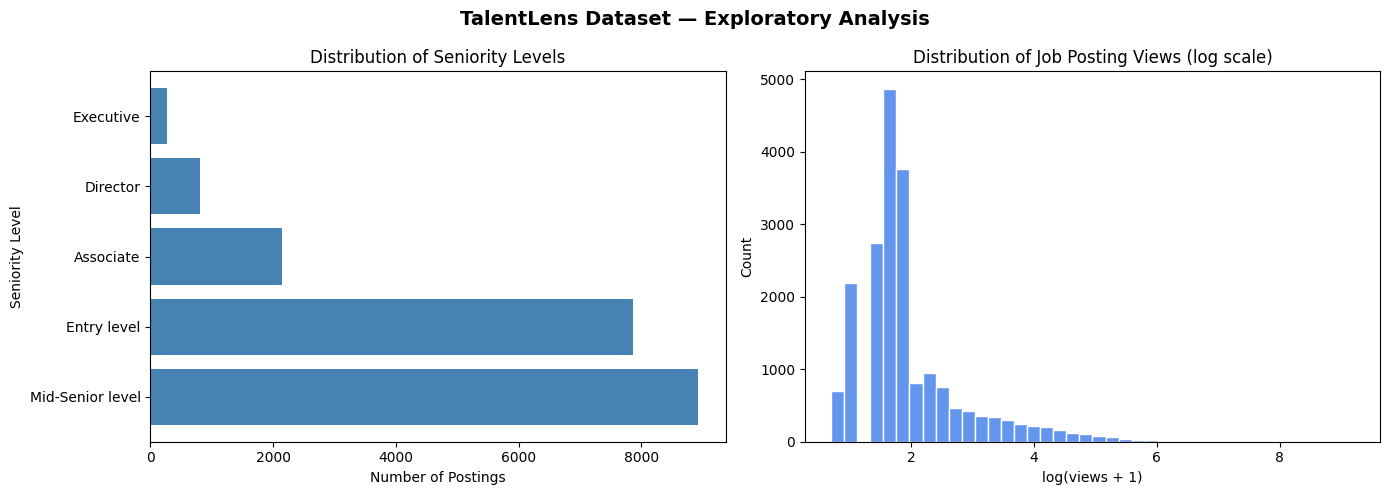


Observation: Notice the class imbalance — Leadership roles are rare.
This will be a key challenge in Part 1.


In [62]:
# ─── Provided plots ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: seniority distribution
counts = df['formatted_experience_level'].value_counts()
axes[0].barh(counts.index, counts.values, color='steelblue')
axes[0].set_title('Distribution of Seniority Levels')
axes[0].set_xlabel('Number of Postings')
axes[0].set_ylabel('Seniority Level')

# Right: views distribution (log scale)
views_clean = df['views'].dropna()
axes[1].hist(np.log1p(views_clean), bins=40, color='cornflowerblue', edgecolor='white')
axes[1].set_title('Distribution of Job Posting Views (log scale)')
axes[1].set_xlabel('log(views + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('TalentLens Dataset — Exploratory Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nObservation: Notice the class imbalance — Leadership roles are rare.')
print('This will be a key challenge in Part 1.')

---
# Part 1 — Predicting Job Seniority

**Business context**: Many LinkedIn job postings omit the seniority level. TalentLens wants to automatically predict the tier from the posting's other features so the platform can tag unclassified postings.

You will build a complete supervised learning pipeline: engineer features, handle class imbalance, evaluate with cross-validation, and interpret the results.

## 1.1 — Target Engineering (2 points)

The raw `formatted_experience_level` column has 5 values. Map them to 3 business tiers:

| Raw value | Tier |
|-----------|------|
| Entry level, Associate | **Junior** |
| Mid-Senior level | **Senior** |
| Director, Executive | **Leadership** |

**Tasks:**
1. Create a `seniority_tier` column using `.map()` from numpy (reference: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.map.html).
2. Print the count of each tier using `.value_counts` (as used in the course).

⚠️ When you are asked to use a specific function, please do it.

⚠️ <font color='red'>As you will have to predict the "seniority_tier" below using Machine Learning models, be sure that the new column doesn't contain any error, otherwise you will loose grades for all the Machine Learning questions.</font>

In [63]:
# YOUR CODE HERE

#Create a function that will map the experience level to the accurate business tier.
#We'll pass this function to the map function in the next question.

def seniority_level_to_tier(level):
  if level in ['Entry level', 'Associate']:
    return 'Junior'
  elif level in ['Mid-Senior level']:
    return 'Senior'
  else:
    return 'Leadership'

df["seniority_tier"] = df["formatted_experience_level"].map(seniority_level_to_tier)

In [64]:
# Print the counts
df["seniority_tier"].value_counts()

seniority_tier
Junior        10008
Senior         8924
Leadership     1068
Name: count, dtype: int64

## 1.2 — Feature Engineering (3 points)

Convert raw columns into numerical features suitable for ML models.

**Tasks:**
1. Create a binary `salary_available` flag (1 if `max_salary` is not null, 0 otherwise)
3. Apply `np.log1p()` to `views` and `applies` (reference: https://numpy.org/devdocs/reference/generated/numpy.log1p.html)
4. One-hot encode `formatted_work_type` with `pd.get_dummies(drop_first=True)` to create binary features, like we did in the course
5. Build feature matrix `X_train`, `X_test` and target `y_train`, `y_test`, then do an 80/20 stratified train/test split (`random_state=42` and `stratify=y`)
6. Print the number of rows and columns of both `X_train` and `X_test`.

In [65]:
# YOUR CODE HERE

# Create binary variable (1 if max_salary is not null, 0 otherwise)
df["salary_available"] = df["max_salary"].notnull().astype(int)

# Apply the log of the values for 'views' and 'applies'
df["views"] = np.log1p(df["views"])
df["applies"] = np.log1p(df["applies"])

# Converts each category of 'formatted_work_type' into a separate column with 0s and 1s
df_encoded = pd.get_dummies(
    df,                                 # dataframe
    columns=['formatted_work_type'],    # Column to encode
    drop_first=True                     # Drop first category to avoid redundancy
)


#Separating Features (X) and Target (y)

# Remove the target (seniority_tier) and the categorical features that won't help learn the relationship between X and y
X = df_encoded.drop(['job_id',	'title',	'description', 'company_id','formatted_experience_level','seniority_tier'], axis=1)

# Select just the column with the target we're trying to predict
y = df_encoded['seniority_tier']

X_train, X_test, y_train, y_test = train_test_split(
    X,                    # Features
    y,                    # Target
    test_size=0.20,       # 20% for testing
    random_state=42,      # Ensure reproducibility
    stratify=y            # Keep same churn ratio in train and test
)

In [66]:
# Print size of X_train and X_test
X_train.shape, X_test.shape

((16000, 20), (4000, 20))

## 1.3 — Machine Learning Models and Hyperparameter Tuning

Now that we got our features ready, let's start the cool stuff, meaning training Machine Learning models! In this section, you'll train two Machine Learning models we learned during the course, and a new one. You will have to optimise their parameters (hyperparameter tuning) and decide which one is the best one.

Before selecting the best model, we must optimize each one. A model with default parameters is rarely the best version of itself.

⚠️ **In this section about Machine Learning models, use all the columns from the dataset to predict the seniority level, otherwise you won't come to the right results and you will loose most of the grades for this section.**

### 1.3.1 — Decision Trees (2 points)

Let's start with the basic Decision Tree!

**Tasks:**
1. Use a `for` loop to test `max_depth` from 1 to 20 for a **Decision Tree**.
2. Print the precision, recall and f1-score for each `max_depth`.
3. Based on precision, recall and f1-score, decide the best `max_depth` and **explain your reasoning** in the analysis question below.

In [67]:
# YOUR CODE HERE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# Create list to store the predictions for different depths
predictions = []

# Test multiple depths
for max_depth in range(1, 21):
  model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)            # Returns array of predictions

  predictions.append((max_depth, y_pred))     # Store the depth and predictions

In [68]:
# Print precision, recall and f1-score for the different Decision Trees
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

print("Depth           | Precision  | Recall      | F1 score")
print("----------------|------------|-------------|----------")

results_dt = []      # Create a list to store the results

for depth, y_pred in predictions:

    # Scores
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results_dt.append((depth, precision, recall, f1))              # Save all results

    print(f"{depth:<15} | {precision:.4f}     | {recall:.4f}     | {f1:.4f}")

results_dt = np.array(results_dt)

Depth           | Precision  | Recall      | F1 score
----------------|------------|-------------|----------
1               | 0.6834     | 0.6623     | 0.6376
2               | 0.6834     | 0.6623     | 0.6376
3               | 0.6967     | 0.7035     | 0.6964
4               | 0.7298     | 0.7198     | 0.7076
5               | 0.7202     | 0.7232     | 0.7145
6               | 0.7342     | 0.7275     | 0.7220
7               | 0.7314     | 0.7312     | 0.7265
8               | 0.7317     | 0.7332     | 0.7275
9               | 0.7266     | 0.7292     | 0.7250
10              | 0.7115     | 0.7175     | 0.7125
11              | 0.7068     | 0.7113     | 0.7078
12              | 0.7075     | 0.7123     | 0.7091
13              | 0.7014     | 0.7047     | 0.7023
14              | 0.6880     | 0.6923     | 0.6896
15              | 0.6819     | 0.6845     | 0.6831
16              | 0.6828     | 0.6850     | 0.6838
17              | 0.6718     | 0.6745     | 0.6730
18              | 0.6683

**📝 Analysis Question 1.3.1:**
Based on precision, recall and f1-score, decide the best max_depth and **explain your reasoning**.

---

**Grading notes**:
- You have to be specific and use your own words, based on the results you have just above. Generating a generic AI answer will not give you the grades.
- Your answer has to be specific to the use case of this project, not a generic answer.
- *Reference your specific scores. Discussing about scores values that are not present in your code above will not give you the grades.*

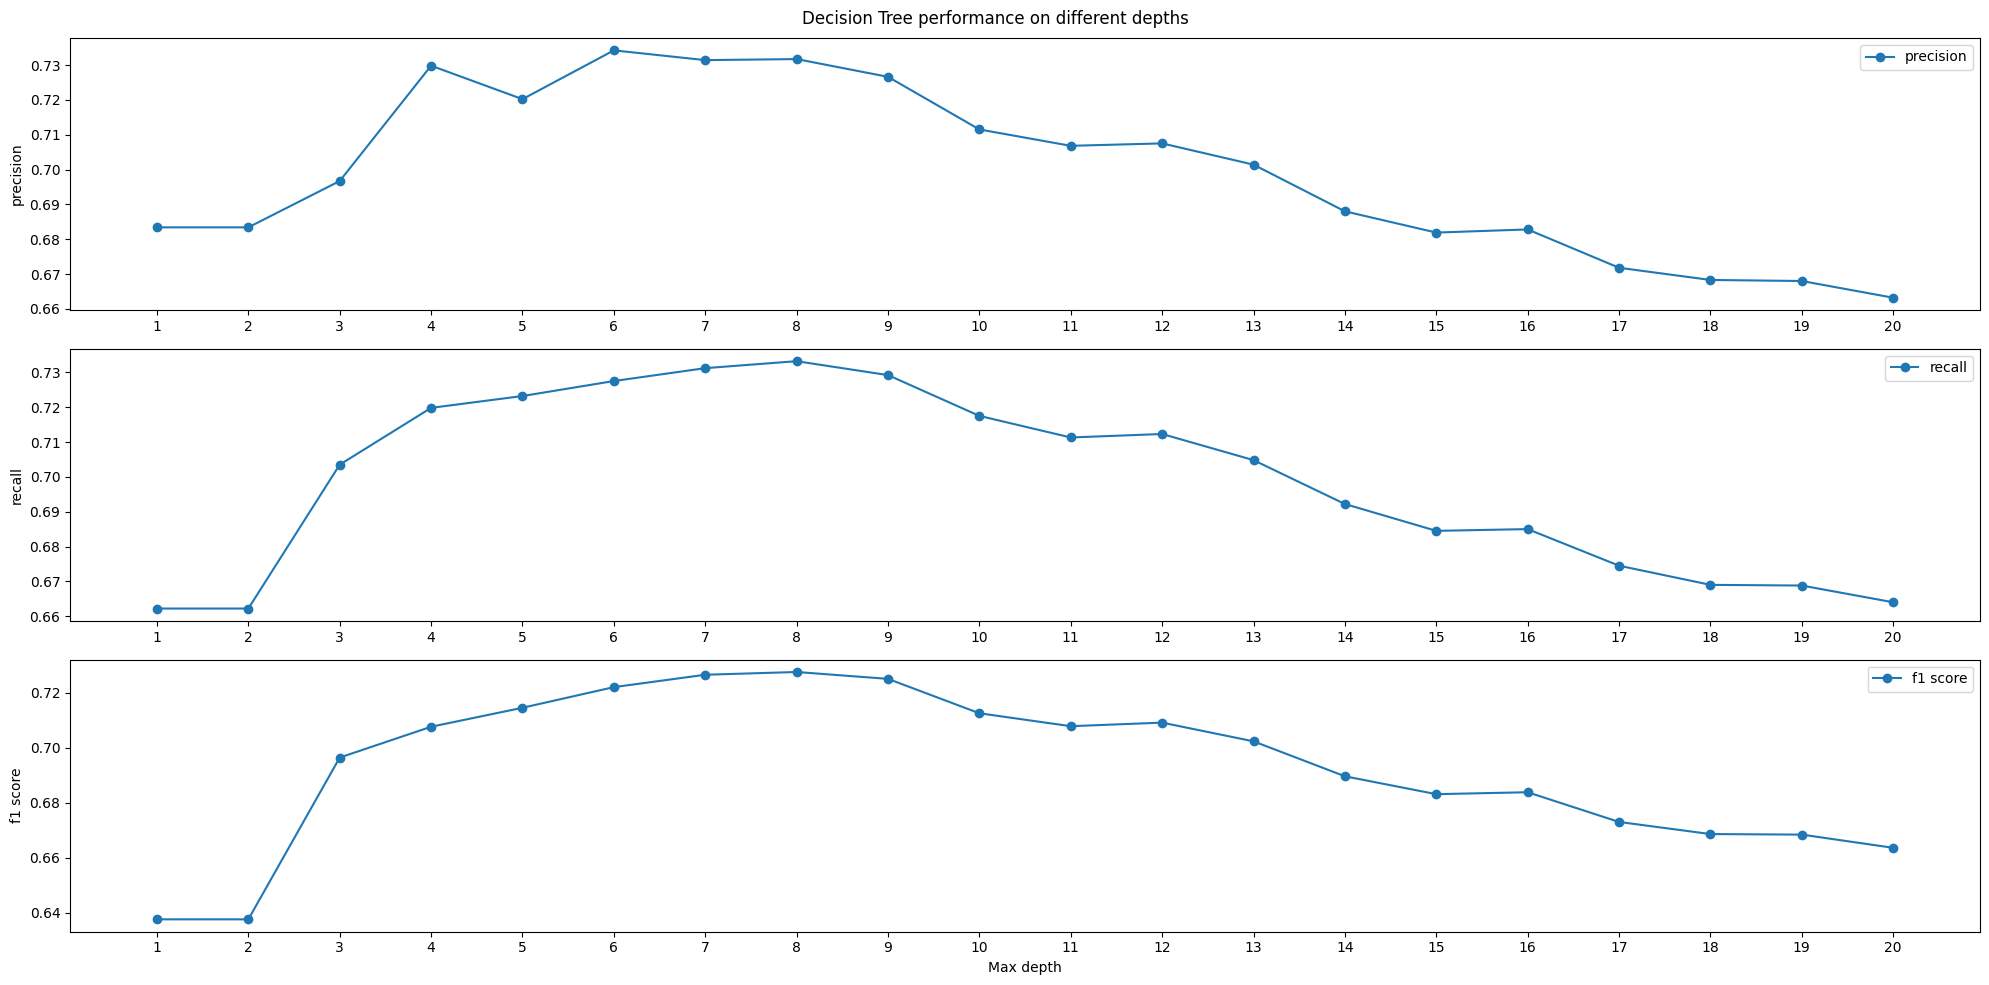

In [69]:
# Plot to visualize F1 score, precision and recall
import matplotlib.pyplot as plt

depths = results_dt[:, 0].astype(int)
precision = results_dt[:, 1].astype(float).round(4)
recall = results_dt[:, 2].astype(float).round(4)
f1 = results_dt[:, 3].astype(float).round(4)

plt.figure(figsize=(20, 10))
plt.suptitle('Decision Tree performance on different depths')

plt.subplot(3, 1, 1)
plt.plot(depths, precision, label='precision', marker='o')
plt.xticks(np.arange(depths.min(), depths.max() + 1, 1))
plt.ylabel('precision')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(depths, recall, label='recall', marker='o')
plt.xticks(np.arange(depths.min(), depths.max() + 1, 1))
plt.ylabel('recall')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(depths, f1, label= 'f1 score', marker='o')
plt.xticks(np.arange(depths.min(), depths.max() + 1, 1))
plt.ylabel('f1 score')
plt.xlabel('Max depth')
plt.legend()

plt.tight_layout()
plt.show()


In [70]:
# Explain your reasoning about the best one here

"""
We selected a maximum depth of 8 because it achieved the highest F1-score (0.7275), while also providing strong precision (0.7317)
and recall (0.7332).

Since the F1-score measures the balance between precision and recall, it is the most appropriate metric for evaluating our
model’s overall classification performance, especially because the dataset is imbalanced.

The results show that performance improves as the depth increases up to 8, after which the F1-score begins to decrease.
This suggests that a depth of 8 provides the best balance between underfitting and overfitting.
"""

best_depth = 8


### 1.3.2 — KNN Classification (2 points)

Now, let's do the KNN Classification!

**Tasks:**
1. Use a `for` loop to test `nb_neighbours` from 1 to 25 for a **KNN Classifier** (do not forget that we need to **scale the data** for KNN, as seen in the course...)
2. Print the precision, recall and f1-score for each `nb_neighbours`.
3. Based on precision, recall and f1-score, decide the best `nb_neighbours` and **explain your reasoning** in the analysis question below.

In [71]:
# YOUR CODE HERE
scaler = StandardScaler()

# Scaling the data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create list to store the predictions for different values of k
results_knn = []

for nb_neighbours in range(1, 26):
  knn = KNeighborsClassifier(n_neighbors=nb_neighbours)
  knn.fit(X_train_scaled, y_train)
  y_pred_knn = knn.predict(X_test_scaled)                # Returns array of predictions

  results_knn.append((nb_neighbours, y_pred_knn))            # Store the depth and predictions

In [72]:
# Print precision, recall and f1-score for the different KNNs
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

print("k               | Precision  | Recall      | F1 score")
print("----------------|------------|-------------|----------")

metrics = []

for k, y_pred in results_knn:

    # Scores
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"{k:<15} | {precision:.4f}     | {recall:.4f}     | {f1:.4f}")

    metrics.append((k, precision, recall, f1))

metrics = np.array(metrics)

k               | Precision  | Recall      | F1 score
----------------|------------|-------------|----------
1               | 0.6729     | 0.6760     | 0.6743
2               | 0.6611     | 0.6498     | 0.6348
3               | 0.6912     | 0.6963     | 0.6903
4               | 0.6956     | 0.6997     | 0.6914
5               | 0.7113     | 0.7160     | 0.7093
6               | 0.7087     | 0.7135     | 0.7056
7               | 0.7227     | 0.7245     | 0.7177
8               | 0.7187     | 0.7228     | 0.7148
9               | 0.7322     | 0.7322     | 0.7246
10              | 0.7292     | 0.7325     | 0.7242
11              | 0.7351     | 0.7345     | 0.7270
12              | 0.7347     | 0.7375     | 0.7292
13              | 0.7396     | 0.7390     | 0.7311
14              | 0.7340     | 0.7362     | 0.7275
15              | 0.7378     | 0.7390     | 0.7307
16              | 0.7350     | 0.7372     | 0.7281
17              | 0.7356     | 0.7365     | 0.7276
18              | 0.7312

**📝 Analysis Question 1.3.2:**
Based on precision, recall and f1-score, decide the best nb_neighbours and **explain your reasoning**.

---

**Grading notes**:
- You have to be specific and use your own words, based on the results you have just above. Generating a generic AI answer will not give you the grades.
- Your answer has to be specific to the use case of this project, not a generic answer.
- *Reference your specific scores. Discussing about scores values that are not present in your code above will not give you the grades.*

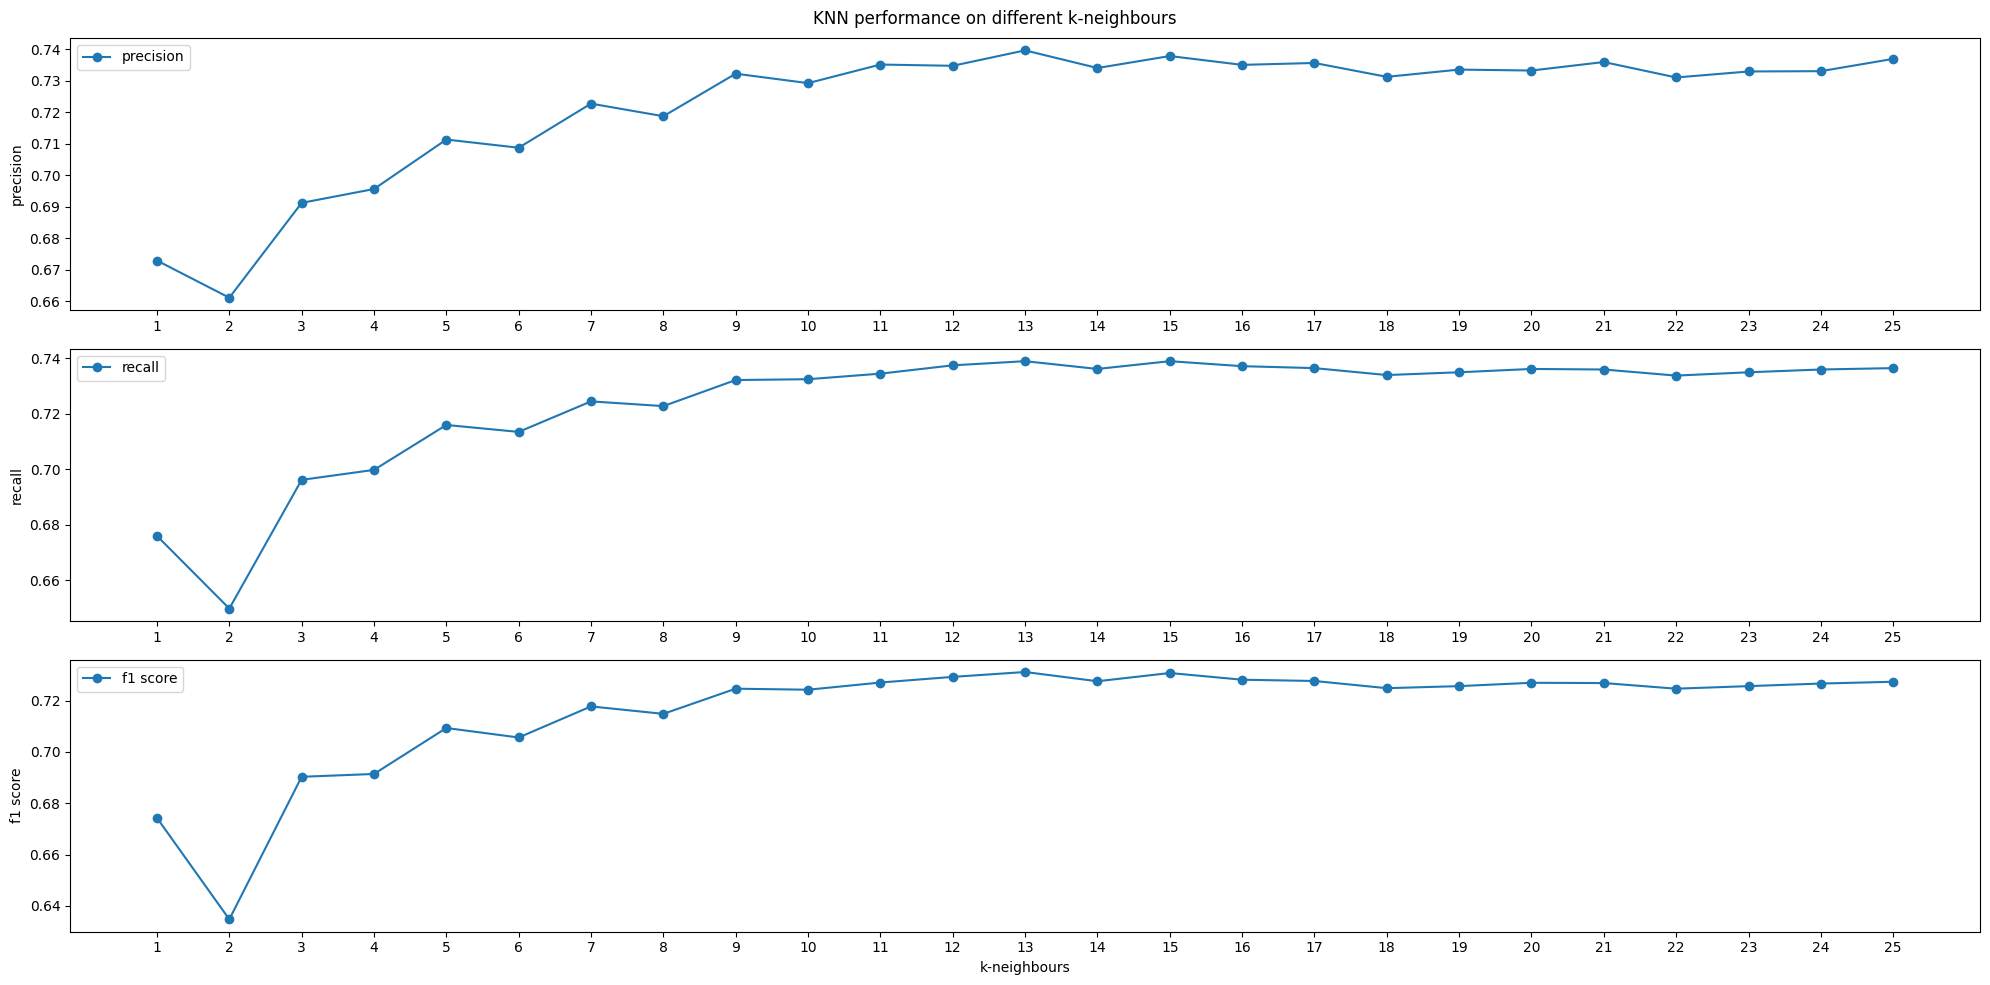

In [73]:
k = metrics[:, 0].astype(int)
precision = metrics[:, 1].astype(float).round(4)
recall = metrics[:, 2].astype(float).round(4)
f1 = metrics[:, 3].astype(float).round(4)

plt.figure(figsize=(20, 10))
plt.suptitle('KNN performance on different k-neighbours')

plt.subplot(3, 1, 1)
plt.plot(k, precision, label='precision', marker='o')
plt.xticks(np.arange(k.min(), k.max() + 1, 1))
plt.ylabel('precision')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(k, recall, label='recall', marker='o')
plt.xticks(np.arange(k.min(), k.max() + 1, 1))
plt.ylabel('recall')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(k, f1, label= 'f1 score', marker='o')
plt.xticks(np.arange(k.min(), k.max() + 1, 1))
plt.ylabel('f1 score')
plt.xlabel('k-neighbours')
plt.legend()

plt.tight_layout()
plt.show()

In [74]:
# Explain your reasoning about the best one here
"""

We selected k = 13 because it achieved the highest F1-score (0.7311), precision (0.7396) and one of the highest recall values (0.7390).

Since the F1-score measures the balance between precision and recall, it is the most appropriate metric for evaluating the
overall classification performance, especially since our dataset is imbalanced. The dataset contains significantly more junior
and senior positions than leadership roles, which could bias the model toward predicting the majority classes more frequently.

The F1 score is high only if both precision and recall are high. If one is low, the F1 drops a lot.

Therefore, it is the best metric to look at in our case since it prevents the model from favoring the majority class (junior
and senior tier) and ignoring the minority class (leadership).
"""

best_k = 13

### 1.3.3 — Logistic Regression (2 points)

This is a new Machine Learning model! (reference: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

You have to use the Logistic Regression implementation from sklearn, as shown in the reference link just above.

**Tasks:**
1. Use a `for` loop to test `C` parameter with values `[0.001, 0.01, 0.1, 1, 10, 100]` for a **Logistic Regression** (as with KNN, let's first **scale the data** for KNN...)
2. Print the precision, recall and f1-score for each `C`.
3. Based on precision, recall and f1-score, decide the best `C` and **explain your reasoning**  in the analysis question below.

In [75]:
# YOUR CODE HERE
from sklearn.linear_model import LogisticRegression

C = [0.001, 0.01, 0.1, 1, 10, 100]

# Create list to store the predictions for different values of c
results_logistic = []

for c in C:
  logistic_model = LogisticRegression(C=c, random_state=42)
  logistic_model.fit(X_train_scaled, y_train)
  y_pred_logistic = logistic_model.predict(X_test_scaled)     # Returns array of predictions

  results_logistic.append((c, y_pred_logistic))               # Store the depth and predictions


In [76]:
# Print precision, recall and f1-score for the different Logistic Regression models
from sklearn.metrics import precision_score, recall_score, f1_score

print("C               | Precision  | Recall      | F1 score")
print("----------------|------------|-------------|----------")

for c, y_pred in results_logistic:

    # Scores
    precision_logistic = precision_score(y_test, y_pred, average='weighted')
    recall_logistic = recall_score(y_test, y_pred, average='weighted')
    f1_logistic = f1_score(y_test, y_pred, average='weighted')

    print(f"{c:<15} | {precision_logistic:.4f}     | {recall_logistic:.4f}     | {f1_logistic:.4f}")

C               | Precision  | Recall      | F1 score
----------------|------------|-------------|----------
0.001           | 0.7475     | 0.7415     | 0.7254
0.01            | 0.7472     | 0.7475     | 0.7400
0.1             | 0.7486     | 0.7490     | 0.7427
1               | 0.7473     | 0.7485     | 0.7421
10              | 0.7473     | 0.7485     | 0.7421
100             | 0.7473     | 0.7485     | 0.7421


**📝 Analysis Question 1.3.3:**
Based on precision, recall and f1-score, decide the best C and **explain your reasoning**.

---

**Grading notes**:
- You have to be specific and use your own words, based on the results you have just above. Generating a generic AI answer will not give you the grades.
- Your answer has to be specific to the use case of this project, not a generic answer.
- *Reference your specific scores. Discussing about scores values that are not present in your code above will not give you the grades.*

In [77]:
# Explain your reasoning about the best one here

"""
C = 0.1 is the best model because it has the highest F1-score (0.7427), and also providing the best balance between precision
and recall. The precision (0.7486) and recall (0.7490) are both slightly higher than for the other values of C,
indicating that the model performs well at correctly identifying classes while minimizing classification errors.

We can also observe that for higher values of C, we see that the model actually performs worse.

"""

best_c = 0.1

### 1.3.4 — Best Model? (2 points)

Now, let's discuss about the best model and **explain your decision**.

---

**Grading notes**:
- You have to be specific and use your own words, based on the results you have just above. Generating a generic AI answer will not give you the grades.
- Your answer has to be specific to the use case of this project, not a generic answer.
- *Reference your specific scores. Discussing about scores values that are not present in your code above will not give you the grades.*

In [78]:
# Explain your reasoning about the best one here
"""
The logistic model is the best model for this case.

Logistic Regression achieved the highest F1-score (0.7427) with C = 0.1, outperforming both KNN (best F1-score = 0.7311)
and the Decision Tree model (best F1-score = 0.7275).

In addition to having the best predictive performance, Logistic Regression is also well suited for this type of structured
HR dataset. Most of the features used in the model such as salary, company size, number of applications, remote status, and
work type are numerical or binary variables that Logistic Regression handles well.


"""

'\nThe logistic model is the best model for this case.\n\nLogistic Regression achieved the highest F1-score (0.7427) with C = 0.1, outperforming both KNN (best F1-score = 0.7311)\nand the Decision Tree model (best F1-score = 0.7275).\n\nIn addition to having the best predictive performance, Logistic Regression is also well suited for this type of structured\nHR dataset. Most of the features used in the model such as salary, company size, number of applications, remote status, and\nwork type are numerical or binary variables that Logistic Regression handles well.\n\n\n'

## 1.4 — Cross-Validation (3 points)

So far you tested on a single 80/20 split. **Cross-validation (CV)** gives a more reliable estimate by repeating the process 5 times with different splits, and averaging the scores.

We use `f1_macro` as the scoring metric — it averages F1 across all classes equally, which is appropriate when classes are imbalanced.

**Tasks:**
1. Run `cross_val_score` with a cross-validation equal to 5, and F1-score as the scoring metric, for **the 3 classifiers** with the best parameter values you found (reference: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)
2. For each classifier, print the mean F1-score and the standard deviation of these F1-scores (reference: https://www.w3schools.com/python/ref_stat_stdev.asp)
3. Comment the best model based on mean f1-score and standard deviation, and store it in `best_model`, and **explain your decision** in the analysis question below.

In [79]:
# YOUR CODE HERE

# Store all the models tested with the best parameters found

# We store the unscaled model for decision trees
unscaled_model = {
    "Decision Tree": DecisionTreeClassifier(max_depth=best_depth, random_state=42)
}


# We store the scaled model for KNN and logistic regression since they need scaling
scaled_models = {
    "KNN": KNeighborsClassifier(n_neighbors=best_k),
    "Logistic Regression": LogisticRegression(C=best_c, random_state=42)
}


In [80]:
# Print mean f1-scores and standard deviations
import statistics
from sklearn.model_selection import cross_val_score

print("Classifier               | Mean F1    | Std F1")
print("-------------------------|------------|---------")

for name, model in unscaled_model.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1_macro'
    )

    mean_f1 = scores.mean()
    std_f1 = statistics.stdev(scores)

    print(f"{name:<24} | {mean_f1:.4f}     | {std_f1:.4f}")

for name, model in scaled_models.items():

    # Scores
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='f1_macro'
    )

    # Calculate the mean and standard deviation of the F1 score
    mean_f1 = scores.mean()
    std_f1 = statistics.stdev(scores)

    print(f"{name:<24} | {mean_f1:.4f}     | {std_f1:.4f}")

Classifier               | Mean F1    | Std F1
-------------------------|------------|---------
Decision Tree            | 0.6071     | 0.0161
KNN                      | 0.5991     | 0.0133
Logistic Regression      | 0.6402     | 0.0104


**📝 Analysis Question 1.4:**
Based on mean f1-scores and standard deviation, decide the best_model and **explain your reasoning**.

⚠️ You will have to understand what is the standard deviation in order to be able to answer this question.

---

**Grading notes**:
- You have to be specific and use your own words, based on the results you have just above. Generating a generic AI answer will not give you the grades.
- Your answer has to be specific to the use case of this project, not a generic answer.
- *Reference your specific scores. Discussing about scores values that are not present in your code above will not give you the grades.*

In [81]:
# Explain the best model based on
"""
After cross-validation, we can see that the best model still is Logistic Regression, like we thought.

The Logistic Regression achieved the highest mean F1-score (0.7427), which indicates the best overall balance between precision and
recall across the classes. F1-score is most relevant metric in our case because there is a class imbalance.

In addition, the model has the lowest standard deviation (0.0104), meaning that it is consistently outperforming across the
different validation folds.

Decision Tree has a much lower F1-score (0.6071), alongside a higher standard deviation (0.0161), making it underperform overall, as expected.
KNN performs better than Decision Tree but has a slightly lower F1-score (0.5991) and higher standard deviation than Logistic Regression (0.0133).

For these reasons, the best model in our case remains as the Logistic Regression one.
"""

'\nAfter cross-validation, we can see that the best model still is Logistic Regression, like we thought.\n\nThe Logistic Regression achieved the highest mean F1-score (0.7427), which indicates the best overall balance between precision and\nrecall across the classes. F1-score is most relevant metric in our case because there is a class imbalance.\n\nIn addition, the model has the lowest standard deviation (0.0104), meaning that it is consistently outperforming across the\ndifferent validation folds.\n\nDecision Tree has a much lower F1-score (0.6071), alongside a higher standard deviation (0.0161), making it underperform overall, as expected.\nKNN performs better than Decision Tree but has a slightly lower F1-score (0.5991) and higher standard deviation than Logistic Regression (0.0133).\n\nFor these reasons, the best model in our case remains as the Logistic Regression one.\n'

## 1.5 — Feature Importance (3 points)

Feature importance tells us which variables had the most influence on seniority predictions.

**Note:** Feature importance is natively available for Decision Trees (`.feature_importances_`). So reuse your Decision Tree with its best parameter values, even though it was not the best model in 1.4.

**Tasks:**
1. Extract and plot feature importances as a **horizontal bar chart** (sorted, labeled), **using the "seaborn" library** as seen during the course.
3. Answer the analysis question below.

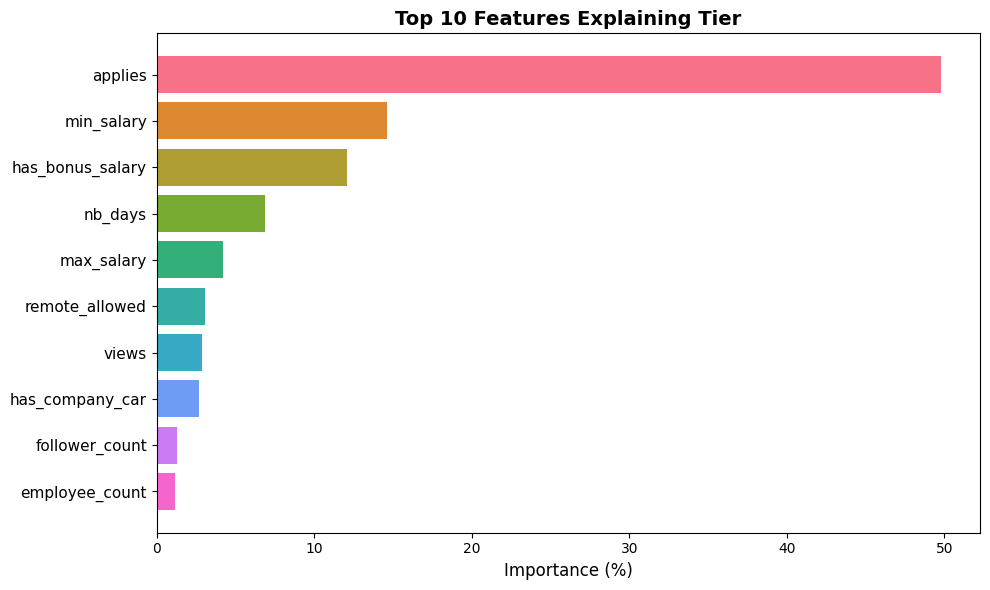

In [82]:
# YOUR ANSWER HERE...

# Create variable for our Decision Tree with its best parameter values
best_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_dt.fit(X_train, y_train)

# Array of importance values
importances = best_dt.feature_importances_

#Extract feature importances from our best model
feature_names = X_train.columns.tolist()
importances = best_dt.feature_importances_

# Create a DataFrame and sort by importance
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
    'importance_pct': importances * 100
}).sort_values('importance', ascending=False).reset_index(drop=True)


# Display the 10 more important features
top_n = 10
top_features = feature_importance_df.head(top_n)

# Create plot
plt.figure(figsize=(10, 6))
bars = plt.barh(
    range(top_n),
    top_features['importance_pct'],
    color=sns.color_palette("husl", top_n)
)
plt.yticks(range(top_n), top_features['feature'], fontsize=11)
plt.xlabel('Importance (%)', fontsize=12)
plt.title('Top 10 Features Explaining Tier', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()   # Features in descending order (most important features at the top)
plt.tight_layout()
plt.show()


**📝 Analysis Question 1.5:**
Does this list of most important features make intuitive business sense to you? Are there any **surprising** features — ones you would not have expected to matter, or the opposite?

---

**Grading notes**:
- You have to be specific and use your own words, based on the results you have just above. Generating a generic AI answer will not give you the grades.
- Your answer has to be specific to the use case of this project, not a generic answer.
- *Reference your specific importance values. Discussing about importance values that are not present in your code above will not give you the grades.*

In [83]:
# YOUR ANSWER HERE...
"""
Overall, most of the feature importance results are consistent with business expectations.


Compensation-related variables align with how experience levels are typically rewarded in the labor market.

- min_salary, max_salary, has_bonus_salary:
  --> Higher salary usually reflect higher seniority. Bonuses are more common in higher positions.

- has_company_car:
  --> Higher positions usually have better rewards, such as a company car.



Surprising features:

  - remote_allowed:
    --> This is somewhat surprising because remote work is not directly related to seniority level.
        Flexibility in work location is generally associated with company policy or industry practices rather than experience level itself.

  - views and nb_days:
    --> The number of views and the duration of a posting are unexpected predictors because they describe the popularity
        or visibility of a job posting rather than the actual responsibilities or experience required for the role.

  - applies:
    --> The number of applicants is surprising because candidate engagement is not an inherent characteristic of seniority.
        Seniority is usually defined by responsibilities, experience, or compensation rather than by how many people apply.

  - follower_count and employee_count:
    --> Company popularity and company size are not direct indicators of job seniority.
        A role can be junior or senior regardless of how large or well-known the company is.


Features with surprisingly low importance:
  - n_skills:
    ---> This is unexpected because senior positions are generally assumed to require broader or more advanced skill sets.
        So, we would normally expect the number of required skills to play a stronger role in predicting seniority.

"""

'\nOverall, most of the feature importance results are consistent with business expectations.\n\n\nCompensation-related variables align with how experience levels are typically rewarded in the labor market.\n\n- min_salary, max_salary, has_bonus_salary:\n  --> Higher salary usually reflect higher seniority. Bonuses are more common in higher positions.\n\n- has_company_car:\n  --> Higher positions usually have better rewards, such as a company car.\n\n\n\nSurprising features:\n\n  - remote_allowed:\n    --> This is somewhat surprising because remote work is not directly related to seniority level.\n        Flexibility in work location is generally associated with company policy or industry practices rather than experience level itself.\n\n  - views and nb_days:\n    --> The number of views and the duration of a posting are unexpected predictors because they describe the popularity\n        or visibility of a job posting rather than the actual responsibilities or experience required for 

---
# Part 2 — Segmenting the Job Market

**Business context**: TalentLens wants to discover *natural clusters* of roles that go beyond official job titles. This powers a 'Jobs like this one' recommendation feature and helps employers understand how their posting compares to the market.

Unlike Part 1, this is **unsupervised** — there are no correct labels. Success is measured by how interpretable and business-meaningful the clusters are.

## 2.1 — Building the Combined Feature Matrix (3 points)

In class, you clustered users by movie ratings — a purely numerical matrix. Here you will combine **structured features** (salary, remote, work type) with **text features** (job descriptions) into a single matrix, to cluster the job posts.

Remember that K-means clustering asks for numerical features. Therefore, we will first need to compute TF-IDF features of job descriptions, so that we have numerical features for them too.

**Tasks:**
1. First compute a TF-IDF with `max_features=50` and `stop_words='english'` on the job explanations (the computed TF-IDF features
2. Reuse the `X` matrix from part 1, containing all the structured features, and combine it with the TF-IDF features, and name your variable `X_combined`.
3. Finally, do not forget to scale the values in `X_combined`, as clustering needs scaled values.

Remark: The computed TF-IDF features is a sparse matrix, you will first have to transform into a dense matrix (using the function `.toarray()` will do the trick).

In [110]:
# TF-IDF

tfidf_vectorizer = TfidfVectorizer(max_features=50, stop_words='english')

description = df['description']
titles = df['title']

X_desc = tfidf_vectorizer.fit_transform(description)
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(X_desc.toarray(), columns=feature_names, index=titles)

In [141]:
tfidf_df

,ability,based,benefits,business,care,company,customer,customers,data,development,...,services,skills,status,support,team,time,training,work,working,years
title,,,,,,,,,,,,,,,,,,,,,
Corporate Development M&A Senior Associate,0.000000,0.000000,0.148015,0.465339,0.000000,0.140627,0.000000,0.000000,0.191664,0.335919,...,0.000000,0.123135,0.000000,0.000000,0.116627,0.000000,0.170180,0.106052,0.301199,0.128921
Accounting Professional,0.000000,0.245181,0.223982,0.078241,0.101581,0.212802,0.000000,0.188577,0.193356,0.000000,...,0.083331,0.124221,0.326786,0.000000,0.235312,0.200874,0.000000,0.320964,0.075964,0.065030
Part Time Retail Merchandiser Floater - Corpus Christi TX 78413,0.120974,0.070571,0.064469,0.067561,0.087715,0.000000,0.000000,0.081418,0.000000,0.000000,...,0.000000,0.053632,0.000000,0.187522,0.152394,0.404727,0.074124,0.508112,0.065595,0.056153
Scrum Master,0.000000,0.131306,0.299882,0.000000,0.000000,0.056983,0.067459,0.000000,0.000000,0.272232,...,0.066941,0.049895,0.131257,0.116302,0.330804,0.215155,0.000000,0.257837,0.122047,0.104479
"Senior Coordinator, Talent Acquisition & Development",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.089818,0.708381,...,0.154836,0.000000,0.000000,0.067252,0.218614,0.000000,0.318999,0.198792,0.000000,0.120830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Chief of Staff,0.111534,0.000000,0.000000,0.249156,0.000000,0.000000,0.267416,0.000000,0.153934,0.269791,...,0.000000,0.197790,0.000000,0.230520,0.093668,0.000000,0.000000,0.340701,0.000000,0.000000
Staff Accountant,0.000000,0.000000,0.000000,0.000000,0.000000,0.410166,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.376025
"Senior Associate, Treasury Accounting",0.000000,0.114272,0.052196,0.328192,0.000000,0.099181,0.000000,0.197753,0.067588,0.000000,...,0.116514,0.000000,0.285572,0.151822,0.205635,0.093621,0.000000,0.037398,0.000000,0.090925


In [118]:
X

,max_salary,views,min_salary,applies,remote_allowed,employee_count,follower_count,company_size,n_skills,n_benefits,has_company_car,nb_days,has_bonus_salary,salary_available,formatted_work_type_Full-time,formatted_work_type_Internship,formatted_work_type_Other,formatted_work_type_Part-time,formatted_work_type_Temporary,formatted_work_type_Volunteer
0,44457.836236,5.049856,44457.836236,0.693147,1,13.0,46256.0,1.0,2,0,False,31,False,1,True,False,False,False,False,False
1,214713.622527,2.079442,128999.139836,3.951244,1,9359.0,253648.0,7.0,2,0,False,35,False,1,True,False,False,False,False,False
2,10000.000000,2.079442,0.000000,4.454347,1,16056.0,94628.0,7.0,2,0,False,20,True,1,False,False,False,True,False,False
3,98739.852319,1.386294,98739.852319,3.737670,1,19894.0,217054.0,7.0,2,0,False,20,True,1,True,False,False,False,False,False
4,156717.106972,1.609438,109640.600397,2.833213,0,365.0,169699.0,3.0,1,0,False,14,False,1,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,124800.051514,1.098612,0.000000,0.693147,1,215.0,78447.0,3.0,1,0,False,45,False,1,False,False,False,False,False,False
19996,111106.157715,3.135494,111106.157715,1.609438,0,4.0,1699.0,1.0,1,0,False,26,False,1,False,False,False,False,False,False
19997,41983.714952,1.791759,10811.266078,2.890372,1,55249.0,699842.0,7.0,2,0,False,27,False,1,True,False,False,False,False,False
19998,171161.264234,1.945910,171161.264234,3.610918,1,9790.0,284604.0,6.0,1,0,False,11,False,1,True,False,False,False,False,False


In [121]:
# X_combined + Scaling
scaler = StandardScaler()

X_combined = pd.concat([X.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)
X_combined_scaled = scaler.fit_transform(X_combined)

## 2.2 — Finding the Optimal Number of Clusters (2 points)

Use the **silhouette score** to determine the best K. Then justify your choice from a business perspective.

**Tasks:**

1. Use the `X_combined` matrix and run K-Means for K = 2 to 10
2. Plot the silhouette score
3. Choose the best K

In [129]:
results = []

print("k               | Silhouette ")
print("----------------|------------")

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_combined_scaled)
    score = silhouette_score(X_combined_scaled, model.labels_, metric='euclidean')
    results.append((k, score))
    print(f"{k:<15} | {score:.4f}")

results = np.array(results)

k               | Silhouette
----------------|------------
2               | 0.0398
2               | 0.0398
3               | 0.0367
3               | 0.0367
4               | 0.0321
4               | 0.0321
5               | 0.0306
5               | 0.0306
6               | 0.0346
6               | 0.0346
7               | 0.0390
7               | 0.0390
8               | 0.0375
8               | 0.0375
9               | 0.0408
9               | 0.0408
10              | 0.0324
10              | 0.0324


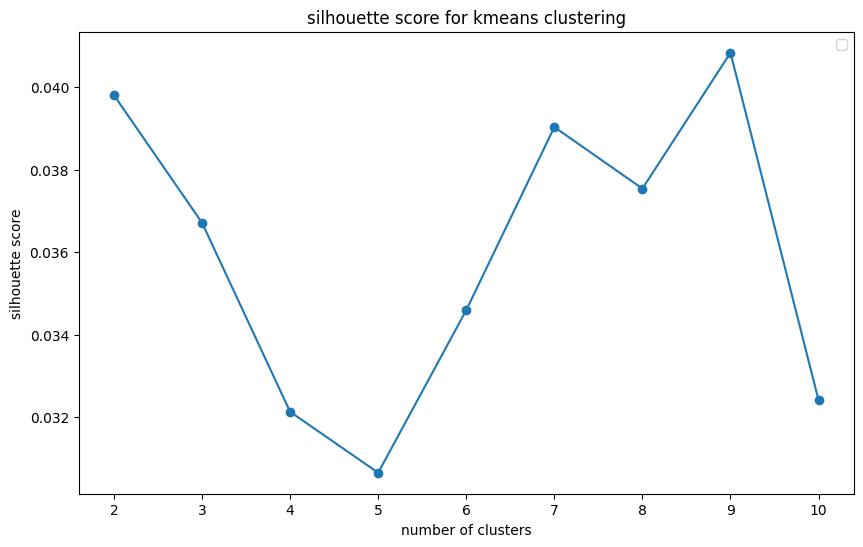

In [123]:
plt.figure(figsize=(10, 6))
plt.title('silhouette score for kmeans clustering')
plt.plot(results[:, 0].astype(int), results[:, 1].astype(float), marker='o')
plt.xlabel('number of clusters')
plt.ylabel('silhouette score')
plt.legend()
plt.show()


k               | Inertia
----------------|------------
2               | 1329442.6192
2               | 1329442.6192
3               | 1294686.8265
3               | 1294686.8265
4               | 1268836.3685
4               | 1268836.3685
5               | 1248958.8898
5               | 1248958.8898
6               | 1221387.4860
6               | 1221387.4860
7               | 1207545.2507
7               | 1207545.2507
8               | 1187581.0777
8               | 1187581.0777
9               | 1167521.0556
9               | 1167521.0556
10              | 1157727.8715
10              | 1157727.8715


k               | Inertia
----------------|------------
2               | 1329442.6192
2               | 1329442.6192
3               | 1294686.8265
3               | 1294686.8265
4               | 1268836.3685
4               | 1268836.3685
5               | 1248958.8898
5               | 1248958.8898
6               | 1221387.4860
6               | 1221387.4860
7               | 1207545.2507
7               | 1207545.2507
8               | 1187581.0777
8               | 1187581.0777
9               | 1167521.0556
9               | 1167521.0556
10              | 1157727.8715
10              | 1157727.8715


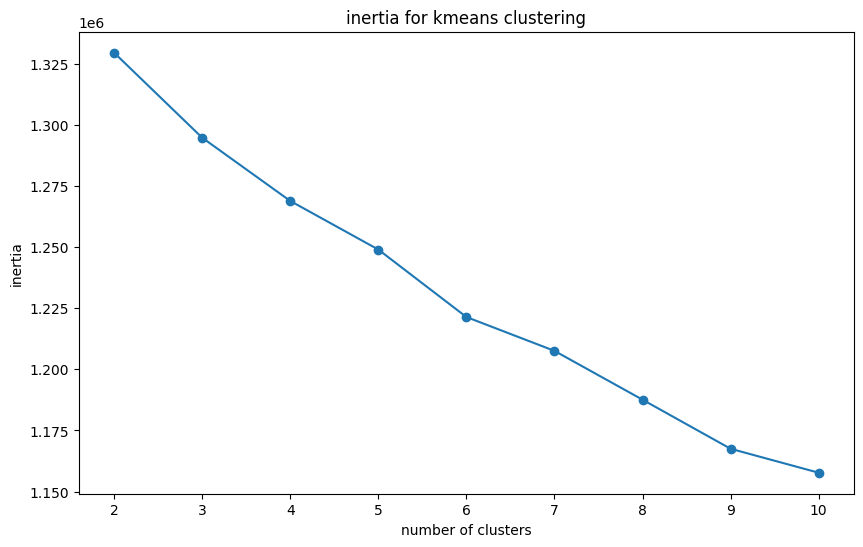

In [130]:
results = []

print("k               | Inertia ")
print("----------------|------------")

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_combined_scaled)
    score = model.inertia_
    results.append((k, score))
    print(f"{k:<15} | {score:.4f}")

results = np.array(results)

plt.figure(figsize=(10, 6))
plt.title('inertia for kmeans clustering')
plt.plot(results[:, 0].astype(int), results[:, 1].astype(float), marker='o')
plt.xlabel('number of clusters')
plt.ylabel('inertia')
plt.legend()
plt.show()

In [131]:
# Write your "best_k" value here

''''
The range of the silhouette scores demonstrates that, for the given data, a change in k between
2 and 10 does not significantly improve the clustering quality, as all scores are relatively close.

Even though the silhouette method advises for the highest value, after checking the inertia we can
conclude that the values accumulate noise from being too similar. Therefore, picking a mid-ground
between both metrics should give us a good level of clusters.

Since we should see clusters that overlap and are not very coherent as the k-neighbours grow,
we have chosen 3 as the best k. This avoids values with lower silhouette scores as it maximizes
the delta between inertia of one cluster and its previous one.

An answer to this phenomenon could be derived from the fact that the tf-idf dataset created has
only 50 features for 20000 samples, which probably does not capture enough singularities in the data.

Another fact to note is that, as we are dealing with data from job postings, they tend to have
lots of similarities, being harder to distinguish between clusters.
'''
best_k = 3

Selected BEST_K = 3


## 2.3 — Dimensionality Reduction (4 points)

Your combined feature matrix `X_combined` has many dimensions — far too many to visualize directly. In order to still visualize the matrix, we will use two dimensionality reduction methods:
- **PCA (Principal Component Analysis)**: simple (and linear) dimensionality reduction method (https://en.wikipedia.org/wiki/Principal_component_analysis).
- **t-SNE**: complex (non-linear) dimensionality reduction method (https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding).

The goal will be dimensionality reduction methods to compress data to 2 dimensions so you can plot it, while preserving as much variation as possible.

**Tasks:**
1. Train your final K-Means with `BEST_K`, in order to have the cluster labels.
2. Apply PCA to reduce your dataset `X_combined` to 2 dimensions and to 3 dimensions.
3. Create two plots, one with the 2 dimensions and one with the 3 dimensions. Use the cluster label to colorize the data points (we have already colorized data points during the course!)


4. Apply t-SNE to reduce your dataset `X_combined` to 2 dimensions and to 3 dimensions.
5. Create two plots, one with the 2 dimensions and one with the 3 dimensions. Use the cluster label to colorize the data points (we have already colorized data points during the course!)

6. Answer the analysis question below. Comment on the different plots you created. Is there a method you prefer for this task? Why?

In [132]:
# Train your final K-Means

model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
yknn = model.fit(X_combined_scaled).labels_

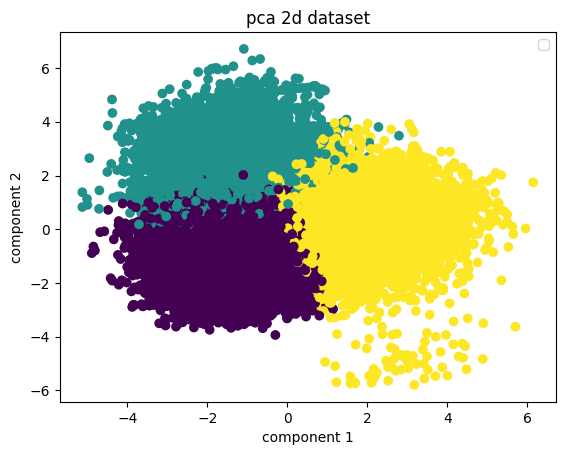

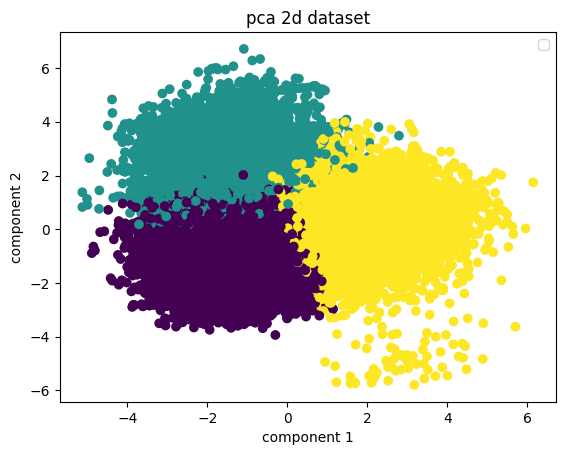

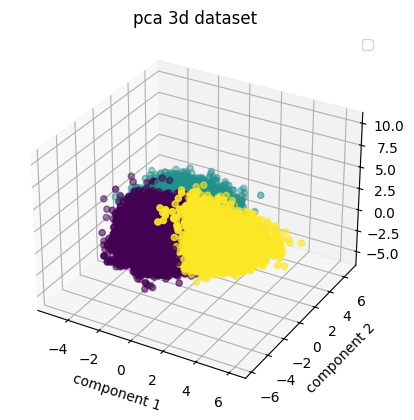

In [133]:
# PCA

pca2d = PCA(n_components=2, random_state=42)
x2d = pca2d.fit_transform(X_combined_scaled)
labels = model.labels_

pca3d = PCA(n_components=3, random_state=42)
x3d = pca3d.fit_transform(X_combined_scaled)

plt.scatter(x2d[:, 0], x2d[:, 1], c=labels)
plt.title('pca 2d dataset')
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.legend()
plt.show()

plot = plt.axes(projection='3d')
plot.scatter(x3d[:, 0], x3d[:, 1], x3d[:, 2], c=labels)
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.title('pca 3d dataset')
plt.legend()
plt.show()

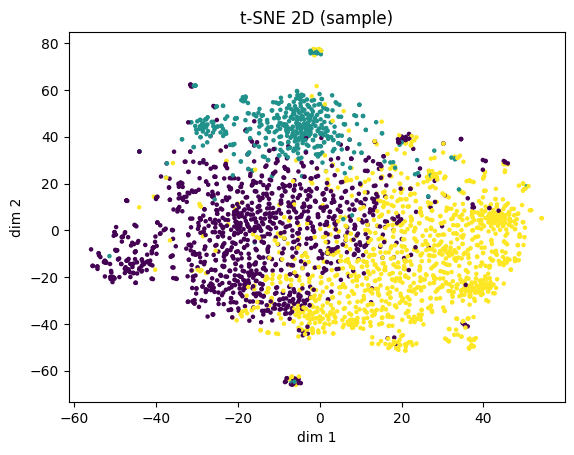

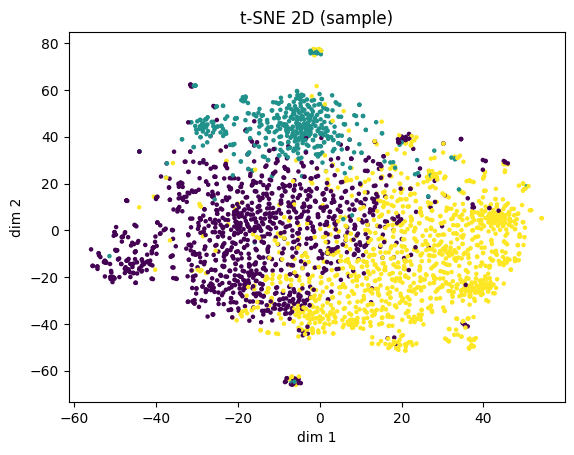

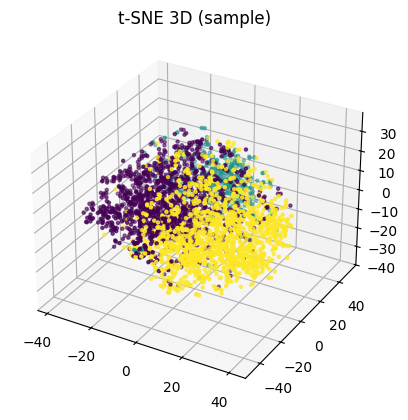

In [134]:
# t-SNE
from sklearn.manifold import TSNE

tsne2d = TSNE(n_components=2, random_state=42)
x2d = tsne2d.fit_transform(X_combined_scaled)

tsne3d = TSNE(n_components=3, random_state=42)
x3d = tsne3d.fit_transform(X_combined_scaled)

In [ ]:
x2d.shape, x3d.shape

((20000, 2), (20000, 3))

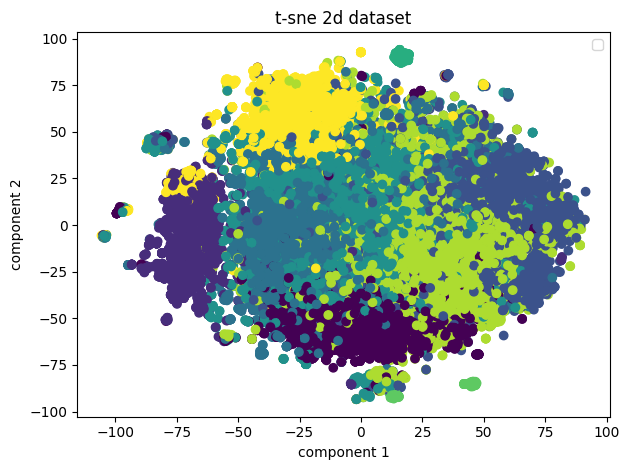

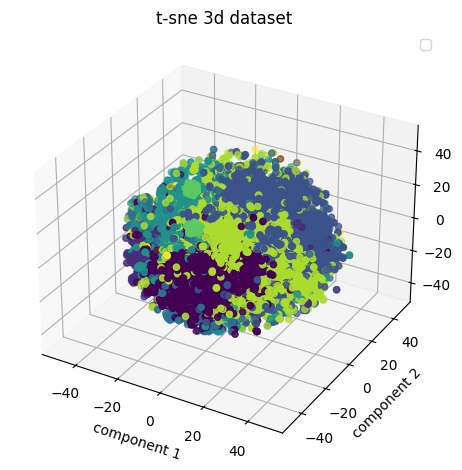

In [ ]:
plt.scatter(x2d[:, 0], x2d[:, 1], c=labels)
plt.title('t-sne 2d dataset')
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.legend()
plt.tight_layout()
plt.show()

plot = plt.axes(projection='3d')
plot.scatter(x3d[:, 0], x3d[:, 1], x3d[:, 2], c=labels)
plt.title('t-sne 3d dataset')
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.legend()

plt.tight_layout()
plt.show()

**📝 Analysis Question 2.3:**
Comment on the four different plots you created. Is there a method you prefer for this task? Why?

---

**Grading notes**:
- You have to be specific and use your own words, based on the results you have just above. Generating a generic AI answer will not give you the grades.
- Your answer has to be specific to the use case of this project, not a generic answer.
- *Describe what you actually observe in your plots. Explaning something that is not present in your plots will not give you the grades.*

In [ ]:
'''
T-SNE provides a hazy plot of clusters. As this method captures non-linear
relationships in the data, this may be an extrapolation of relations.

PCA, being a linear dimensionality reduction technique, may not capture the complex relationships
between features. However, the visualizations seems to have clearer distinctions between clusters.

The 3D graphs do not seem to give a clearer representation of the dataset, but can really show the 'layers'
of the z axis when used alongside the 2D plots. We would choose the 2D PCA graph to reduce dimensionality 
and present the results.

'''

"\nT-SNE provides a hazy plot of clusters. As this method captures non-linear\nrelationships in the data, this may be an extrapolation of relations.\n\nPCA, being a linear dimensionality reduction technique, may not capture the complex relationships\nbetween features. However, the visualizations seems to have clearer distinctions between clusters.\n\nThe 3D graphs do not seem to give a clearer representation of the dataset, but can really show the 'layers'\nof the z axis when used alongside the 2D plots. We would choose the 2D PCA graph to reduce dimensionality \nand present the results.\n\n"

## 2.4 — Cluster Profiling & Naming (3 points)

Clusters only become useful when you can explain what they represent. In this subsection, you will have to print the cluster centers and based on that, give a descriptive business name to each cluster.

We will again use the optimal number of clusters.

**Tasks:**
1. For each cluster: print the mean of features:
  - Minimum Salary
  - Maximum Salary
  - Has Bonus Salary
  - Has Company Car
  - Number of Days Off
  - Number of Benefits
  - Number of Applies
  - Number of Views
2. Give each cluster a **descriptive business name** in the analysis question below. Use your creativity.

In [ ]:
cluster_name = {
    0: 'Junior',
    1: 'Mid-level',
    2: 'Senior',
}


for l in np.unique(labels):
    print(f'Cluster: {l}, The "{cluster_name[l]}". Mean of features: \n')
    print(f'  -  Minimum Salary: {df['min_salary'][labels == l].mean().round(2)}')
    print(f'  -  Maximum Salary: {df['max_salary'][labels == l].mean().round(2)}')
    print(f'  -  Has Bonus Salary: {df['has_bonus_salary'][labels == l].mean().round(2)}')
    print(f'  -  Has Company Car: {df['has_company_car'][labels == l].mean().round(2)}')
    print(f'  -  Number of Days Off: {df['nb_days'][labels == l].mean().round(2)}')
    print(f'  -  Number of Benefits: {df['n_benefits'][labels == l].mean().round(2)}')
    print(f'  -  Number of Applies: {df['applies'][labels == l].mean().round(2)}')
    print(f'  -  Number of Views: {df['views'][labels == l].mean().round(2)}')
    print('\n----------------------------------------------\n')

Cluster: 0, The "Mid-level Analyst". Mean of features: 

  -  Minimum Salary: 53898.85
  -  Maximum Salary: 99825.65
  -  Has Bonus Salary: 0.27
  -  Has Company Car: 0.09
  -  Number of Days Off: 23.32
  -  Number of Benefits: 0.5
  -  Number of Applies: 3.01
  -  Number of Views: 1.86

----------------------------------------------

Cluster: 1, The "Intern". Mean of features: 

  -  Minimum Salary: 34499.24
  -  Maximum Salary: 73424.81
  -  Has Bonus Salary: 0.17
  -  Has Company Car: 0.05
  -  Number of Days Off: 21.75
  -  Number of Benefits: 0.38
  -  Number of Applies: 3.63
  -  Number of Views: 1.7

----------------------------------------------

Cluster: 2, The "Technical Analyst". Mean of features: 

  -  Minimum Salary: 48470.43
  -  Maximum Salary: 91849.01
  -  Has Bonus Salary: 0.29
  -  Has Company Car: 0.08
  -  Number of Days Off: 23.71
  -  Number of Benefits: 0.33
  -  Number of Applies: 2.74
  -  Number of Views: 2.4

----------------------------------------------



**📝 Analysis Question 2.4:**
Provide cluster names for each of the clusters you defined. Once done, give as well one **specific, concrete** example of how an employer in one of your named clusters might benefit from knowing which cluster their posting falls into.

---

**Grading notes**:
- Your cluster names have to be based on the key characteristics of the clusters, as printed above. Not using the key characteristics you printed above will not give you the grades.
- Your answer has to be specific to the use case of this project, not a generic answer.
- Use your creativity.

In [ ]:
'''
Cluster 0: The Junior.
This cluster represents the lowest salary range, without bonus nor car. It has the biggest number of applies,
even though has virtually no benefits. Here, day offs are the lowest and pay 

Cluster 1: The Mid-level.
This cluster represents the mid-level salary range, it has a bit higher bonus and company car benefits along
with a few more days off then junior positions. It has a moderate number of applies and views. May
represent crucial positions in the company that are not leadership but still require skill and responsibility.

Cluster 2: The Senior
This cluster has the highest salary range, with bonus and company car. This represents the most senior, 
responsible and skilled positions in the company, which are the rarest and most sought after, which also explains 
the high number of views and low number of applies.
----------

Knowing your cluster is good to understand what the candidate is getting into, as most of job postings
are not always well described. For example, one employee may be looking for a senior role, but the job posting,
labeled as "senior", may actually be a mid-level role and vice versa.

For company employment policy, designing the roles following clusters analysis and aligning the benefits package
with the market guarantees a closer match between the company and the candidates, as well as a possibly better employee
retention. As for the candidates, understanding where your profile matches makes a difference in job search. 
Additionally, it helps to develop a career plan and design a path to reach the desired cluster.


'''

'\nCluster 1 name: x\nThis cluster \n\nCluster 2 name: The Intern. \nThis cluster representsm the lowest salary range, without bonus nor car. Although has\nthe biggest number of applies, it has the lowest number of views.\n\nCluster 3: The \n\nCluster 4: The \nThis\n\nCluster 5: The\nThis\n\nCluster 6: The Leader\nThis\n\nCluster 7: The Director\nThis\n\nCluster 8: The\nThis\n\n----------\n\nKnowing your cluster is good to understand what the candidate is getting into, as most of job postings\nare not always well described. For example, one employee may be looking for a senior role, but the job posting,\nlabeled as "senior", may actually be a manager role, which is a leadership position, and vice versa.\n\nAlso for company employment policy, designing the roles following clusters analysis and aligning the benefits package\nwith the market guarantees a closer match between the company and the candidates, as well as a possibly better employee\nretention.\n'

---
# Part 3 — Semantic Job Search Engine + LLM

**Business context**: TalentLens wants a search experience where users describe what they're looking for in plain language and get relevant postings back — even if exact keywords don't match.

You will build this in four stages:
1. **Embedding search** — meaning-based matching
2. **LLM extraction** — structured intelligence from raw descriptions
3. **Interview assistant** — chained LLM calls for personalised preparation

As seen during the course, for the section on sentence embeddings and LLMs, you should be sure that you use a GPU. **Not using any GPU will make your code run forever**. Please do that:

⚠️  Requires GPU: Runtime → Change runtime type → T4 GPU

## 3.1 — Embedding-Based Semantic Search (4 points)

TF-IDF can't recognize that 'software engineer' and 'developer' mean the same thing. Sentence embeddings encode the *meaning* of text, enabling concept-based search.

In this subsection, we will build a Embedding-Based Semantic Search, similar to what we did during the course.

**Tasks:**
1. Using `SentenceTransformer` load the embedding model "all-MiniLM-L6-v2" (same model as the embeddings notebook during the course)
2. Embed a sample of **2,000 descriptions** `df.sample(2000, random_state=42)` (you can use more than 2,000 descriptions, but just keep in mind that it will just run slower). In the end, you should have a sentence embedding for each description
3. Write a `search_embeddings(query, top_n=5)` function. This function will take as input a query, embed the query using the sentence embedding, compare the embedding with the embeddings of your 2,000 (or more) descriptions and return the `top_n` best jobs, based on **cosine similarity**
4. Run your code on **at least 3 queries**, and print the extracted jobs for each query. You will not get the grades for this question if the extracted jobs don't make sense for the used queries (and of course, because of the 2,000 selection, you will not have jobs for every field in your search).

In [ ]:
# ⚠️ Requires GPU: Runtime → Change runtime type → T4 GPU
# Not using any GPU will make your code run forever.

# YOUR CODE HERE
from sentence_transformers import SentenceTransformer

sentence_model = SentenceTransformer('all-MiniLM-L6-v2')


# Sample 2,000 descriptions
sample_df = df.sample(2000, random_state=42).copy()

# Extract descriptions
descriptions = sample_df["description"].fillna("").tolist()

# Compute embeddings
embeddings = sentence_model.encode(descriptions)


def search_embeddings(query, top_n=5):
    # Embed the query
    query_embedding = sentence_model.encode([query])

    # Compute cosine similarities
    similarities = cosine_similarity(query_embedding, embeddings)[0]

    # Get indices of top results
    top_indices = np.argsort(similarities)[::-1][:top_n]

    # Build results dataframe
    results = sample_df.iloc[top_indices].copy()
    results["similarity"] = similarities[top_indices]

    return results[
        ["title", "description", "similarity"]
    ]




modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Print the extracted jobs for each query

queries = [
    "machine learning engineer",
    "data analyst",
    "frontend developer"
]

for query in queries:
    print(f"\nQUERY: {query}")
    print("-" * 60)

    results = search_embeddings(query, top_n=5)

    for idx, row in results.iterrows():
        print(f"\nTitle: {row['title']}")
        print(f"Similarity: {row['similarity']:.4f}")




QUERY: machine learning engineer
------------------------------------------------------------

Title: Sr. Machine Learning Engineer 
Similarity: 0.6729

Title: Design Engineer II - Power Tools
Similarity: 0.5697

Title: Senior Lead Engineer - Generative AI Product Engineering
Similarity: 0.5361

Title: Senior Machine Learning Engineer
Similarity: 0.5339

Title: Senior Engineer - Generative AI Product Engineering (Remote Eligible)
Similarity: 0.5329

QUERY: data analyst
------------------------------------------------------------

Title: Business Analyst
Similarity: 0.6525

Title: Data Engineer
Similarity: 0.5531

Title: Senior Research Data Analyst-DBH
Similarity: 0.5476

Title: Data Analyst/Project Manager
Similarity: 0.5357

Title: Data Scientist
Similarity: 0.5355

QUERY: frontend developer
------------------------------------------------------------

Title: Python Developer
Similarity: 0.6076

Title: Web Developer
Similarity: 0.4897

Title: SharePoint Developer
Similarity: 0.4682


## 3.2 — LLM Structured Extraction (4 points)

In the LLM notebook, you learned prompt engineering. Here you apply it to a practical task: extracting structured information from unstructured job descriptions.

**Goal:** Given a job description, instruct the LLM to return a structured JSON answer:
```json
{"role_type": "technical/business/operations/other",
 "key_skills": ["skill1", "skill2", "skill3"],
 "job_field": "Field of the job",
 "seniority_hint": "Junior/Senior/Leadership"}
```

**Steps:**
1. Load the model (scaffold provided)
2. Write a zero-shot prompt, and instruct the LLM to return a **structured JSON answer**, as seen in the course.
3. Run your zero-shot prompt with 5 postings from different fields. You have to print the job posting and the LLM results for each posting.
4. Write an improved prompt (using few-shot prompting **AND** system prompt instructions), , and instruct the LLM to return a **structured JSON answer**.
5. Run the improved prompt on the **same** 5 postings, and print the postings + the LLM results.
6. Comment on the differences in the LLM results with the two prompts.

In [ ]:
# ─── 3.2: Load the LLM ── run this cell once! ───

# ⚠️ Requires GPU: Runtime → Change runtime type → T4 GPU
# Not using any GPU will make your code run forever.

print('Loading LLM... (~2-3 minutes)')

llm = pipeline(
    'text-generation',
    model='unsloth/Qwen3.5-2B',
    torch_dtype=torch.float16,
    device_map='auto',
    max_new_tokens=300,
    do_sample=False,
)

Loading LLM... (~2-3 minutes)


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

In [ ]:
# Zero-shot prompt

# YOUR CODE HERE

prompt_zero = """
Extract structured information from this job posting.

Return ONLY valid JSON with this exact format:

{{
  "role_type": "",
  "key_skills": [],
  "job_field": "",
  "seniority_hint": ""
}}

Rules:
- role_type must be one of:
  technical, business, operations, other

- key_skills must contain the 3 most important skills mentioned

- seniority_hint must be one of:
  Junior, Senior, Leadership

- Return ONLY JSON
- Do not include explanations

Job description:
{job_posting}
"""

In [ ]:
# Zero-shot run on 5 job postings

# YOUR CODE HERE

# Select 5 postings from different jobs
sample_jobs = df.sample(5, random_state=42)

print("=" * 80)
print("ZERO-SHOT RESULTS")
print("=" * 80)

for i, (_, row) in enumerate(sample_jobs.iterrows(), start=1):

    job_posting = row["description"]

    # Build prompt
    full_prompt = prompt_zero.format(
        job_posting=job_posting[:2000]
    )

    # Run LLM
    response = llm(full_prompt)[0]["generated_text"]

    # Extract generated answer only
    generated_answer = response[len(full_prompt):].strip()

    # Print posting
    print("\n" + "=" * 80)
    print(f"JOB POSTING #{i}")
    print("=" * 80)

    print(job_posting[:1200])

    # Print LLM result
    print("\nLLM RESULT")
    print("-" * 40)

    print(generated_answer)

ZERO-SHOT RESULTS

JOB POSTING #1
We offer a full benefits package, PTO, weekly pay, and more!

Location: Lehi, UT

Pay: $21.50/hour

We help make your world a safer place.

Securitas plays an essential role for our clients and in society. The Flex Security Officer will be monitoring and patrolling different client sites on a variety of schedules. They preserve order while enforcing regulations and directives for client sites pertaining to personnel, visitors, and the area. Strong and reliable performance will earn the Officer consideration for assignment to supervisory or other leadership posts. Ideally, Officers will develop career paths to further growth within the Company. Frequently our Security Officers will provide customer service and information to a client's employees and customers.

Position Requirements: 

Authorized to work in the U.S.18 years of age or olderHigh School Diploma or GED requiredBasic phone & computer skillsCalm, polite, and professional behaviorReliable and 

In [ ]:
# Multi-shot prompt

# YOUR CODE HERE
# Multi-shot prompt


multi_shot_prompt = """You are an expert HR.

Your task is to analyze job postings and extract structured information.

You MUST follow these rules:
- Return ONLY valid JSON
- Do NOT include explanations
- Do NOT include reasoning or <think> tags
- key_skills must contain at most 3 important skills
- role_type must be exactly one of:
  ["technical", "business", "operations", "other"]
- seniority_hint must be exactly one of:
  ["Junior", "Senior", "Leadership"]
- If the seniority is unclear, choose the closest category

Return JSON with this exact structure:

{{
  "role_type": "",
  "key_skills": [],
  "job_field": "",
  "seniority_hint": ""
}}

Example 1:

Job posting:
"We are looking for a Data Scientist with strong Python, SQL and Machine Learning skills.
Candidates should have 5+ years of experience working with predictive models."

JSON:
{{
  "role_type": "technical",
  "key_skills": ["Python", "SQL", "Machine Learning"],
  "job_field": "Data Science",
  "seniority_hint": "Senior"
}}

Example 2:

Job posting:
"Seeking a Marketing Coordinator to manage campaigns, social media and client communications.
Recent graduates are encouraged to apply."

JSON:
{{
  "role_type": "business",
  "key_skills": ["Marketing", "Social Media", "Communication"],
  "job_field": "Marketing",
  "seniority_hint": "Junior"
}}

Example 3:

Job posting:
"Operations Manager needed to supervise logistics teams, coordinate supply chain activities
and improve warehouse performance."

JSON:
{{
  "role_type": "operations",
  "key_skills": ["Logistics", "Supply Chain", "Team Management"],
  "job_field": "Operations",
  "seniority_hint": "Leadership"
}}


Now analyze this job posting.

Job posting:
"{job_posting}"

JSON:
"""

In [ ]:
# Multi-shot run on 5 job postings

# YOUR CODE HERE
# Multi-shot run on 5 job postings

sample_jobs = df.sample(5, random_state=42)

print("=" * 80)
print("MULTI-SHOT RESULTS")
print("=" * 80)

for i, (_, row) in enumerate(sample_jobs.iterrows(), start=1):

    job_posting = row["description"]

    # Build prompt
    full_prompt = multi_shot_prompt.format(
        job_posting=job_posting[:2000]
    )

    # Run LLM
    response = llm(full_prompt)[0]["generated_text"]

    # Extract generated answer only
    generated_answer = response[len(full_prompt):].strip()

    # Print posting
    print("\n" + "=" * 80)
    print(f"JOB POSTING #{i}")
    print("=" * 80)

    print(job_posting[:1200])

    # Print result
    print("\nLLM RESULT")
    print("-" * 40)

    print(generated_answer)

MULTI-SHOT RESULTS

JOB POSTING #1
We offer a full benefits package, PTO, weekly pay, and more!

Location: Lehi, UT

Pay: $21.50/hour

We help make your world a safer place.

Securitas plays an essential role for our clients and in society. The Flex Security Officer will be monitoring and patrolling different client sites on a variety of schedules. They preserve order while enforcing regulations and directives for client sites pertaining to personnel, visitors, and the area. Strong and reliable performance will earn the Officer consideration for assignment to supervisory or other leadership posts. Ideally, Officers will develop career paths to further growth within the Company. Frequently our Security Officers will provide customer service and information to a client's employees and customers.

Position Requirements: 

Authorized to work in the U.S.18 years of age or olderHigh School Diploma or GED requiredBasic phone & computer skillsCalm, polite, and professional behaviorReliable and

KeyboardInterrupt: 

**📝 Analysis Question 3.2:**
Comment on the differences in the LLM results for both prompts.

---

**Grading notes**:
- You have to be specific and use your own words, based on the results you have just above. Generating a generic AI answer will not give you the grades.
- Your answer has to be specific to the use case of this project, not a generic answer.
- *Describe what you actually observe in the JSON results. Explaning something that is not present in your plots will not give you the grades.*

In [ ]:
# YOUR ANSWER HERE
"""
The multi-shot prompt has significantly better results than the zero-shot prompt.

With the zero-shot prompt, the model often didn't follow the required JSON structure, and some outputs contained repeated text, incomplete answers, or unnecessary reasoning.
For example: Job Posting #1 generated repetitive and nonsensical text instead of structured JSON. In Job Posting #4, the model included a long “thinking process” explanation instead of only returning the requested JSON object.
In job postings #5 and #4, the model produced only an incomplete reasoning process, without following the provided structure.


On the other hand, the multi-shot prompt results were much more structured and relevant. For example:

* the Machine Learning Engineer posting was correctly classified as "technical" with relevant skills such as "Machine Learning" and "Python".
* the AV technician role correctly identified technical support
* and the security officer posting was classified as "operations" instead of producing meaningless repetitions.

The multi-shot prompt also reduced hallucinations and improved the quality of the extracted skills and job fields.
However, some issues still remained:

* Most outputs still included a <think> part when the prompt explicitly requested JSON only.


Overall, the multi-shot approach clearly improved the reliability, structure, and relevance of the LLM outputs compared to the zero-shot prompt.
"""

'\nThe multi-shot prompt has significantly better results than the zero-shot prompt.\n\nWith the zero-shot prompt, the model often didn\'t follow the required JSON structure, and some outputs contained repeated text, incomplete answers, or unnecessary reasoning. \nFor example: Job Posting #1 and #5 generated repetitive and nonsensical text instead of structured JSON. In Job Posting #4, the model included a long “thinking process” explanation instead of only returning the requested JSON object. This shows that the model struggled to understand the expected output format using only a single instruction.\n\nOn the other hand, the multi-shot prompt results were much more structured and relevant. For example:\n\n* the Machine Learning Engineer posting was correctly classified as "technical" with relevant skills such as "Machine Learning" and `"Python",\n* the AV technician role correctly identified technical support and troubleshooting skills,\n* and the security officer posting was classif

## 3.3 — Interview Preparation Assistant (4 points)

You've built tools that *find* jobs and *understand* them. Now build something that helps a candidate *prepare* for one.

Given a job description from the dataset, your assistant will have to extract the same structured output than question 3.2, but also generate 5 targeted interview questions and synthetise a personalised preparation strategy.

**Tasks:**
1. Reuse the same structured output from 3.2, by adding 5 targeted interview questions and a personalised preparation strategy.
2. The 5 targetted interview questions should be specific to the structured output from 3.2 (so fields "role_type", "key_skills", "job_field" and "seniority_hint").
3. The synthetised preparation strategy should be 100-150 words long and should be based on the 5 targetted questions.
4. Run your process on 3 job posts from different fields (do not re-use job posts used in previous questions, you should take new ones). You should clearly print the results of your new LLM process.

**Remark**:
- In order for your 5 targetted interview questions to be based on the fields "role_type", "key_skills", "job_field" and "seniority_hint", and for your synthetised preparation strategy to be based on the targetted question, you might have to do **3 LLM calls** for each job posting (one to have the structured output from 3.2, one to have the 5 targetted interview questions and one to have the synthetised preparation strategy), and to link LLM results to the next LLM call, of course.
- For the task 4., keep in mind that you have to print all the results (of the three LLM calls) together, and not only the synthetised preparation strategy from the last LLM call.


In [ ]:
# ⚠️ Requires GPU: Runtime → Change runtime type → T4 GPU
# Not using any GPU will make your code run forever.

# YOUR CODE HERE
# INTERVIEW PREPARATION ASSISTANT


# PROMPT 1 — STRUCTURED EXTRACTION

prompt_extraction = """You are an expert HR.

Your task is to analyze job postings and extract structured information.

You MUST follow these rules:
- Return ONLY valid JSON
- Do NOT include explanations
- Do NOT include reasoning or <think> tags
- key_skills must contain at most 3 important skills
- role_type must be exactly one of:
  ["technical", "business", "operations", "other"]
- seniority_hint must be exactly one of:
  ["Junior", "Senior", "Leadership"]
- If the seniority is unclear, choose the closest category

Return JSON with this exact structure:

{{
  "role_type": "",
  "key_skills": [],
  "job_field": "",
  "seniority_hint": ""
}}

Example 1:

Job posting:
"We are looking for a Data Scientist with strong Python, SQL and Machine Learning skills.
Candidates should have 5+ years of experience working with predictive models."

JSON:
{{
  "role_type": "technical",
  "key_skills": ["Python", "SQL", "Machine Learning"],
  "job_field": "Data Science",
  "seniority_hint": "Senior"
}}

Example 2:

Job posting:
"Seeking a Marketing Coordinator to manage campaigns, social media and client communications.
Recent graduates are encouraged to apply."

JSON:
{{
  "role_type": "business",
  "key_skills": ["Marketing", "Social Media", "Communication"],
  "job_field": "Marketing",
  "seniority_hint": "Junior"
}}

Example 3:

Job posting:
"Operations Manager needed to supervise logistics teams, coordinate supply chain activities
and improve warehouse performance."

JSON:
{{
  "role_type": "operations",
  "key_skills": ["Logistics", "Supply Chain", "Team Management"],
  "job_field": "Operations",
  "seniority_hint": "Leadership"
}}


Now analyze this job posting.

Job posting:
"{job_posting}"

JSON:
"""


# PROMPT 2 — INTERVIEW QUESTIONS

prompt_interview_questions = """You MUST use ALL fields from the structured information:
- role_type → determines whether questions are technical, business, operational, or general
- key_skills → each skill should appear in at least one question
- job_field → questions must be adapted to the industry/domain
- seniority_hint → determines the level of difficulty, responsibility, and leadership expectations

Rules:
- Include both technical and behavioral questions
- Questions must sound realistic and professional
- Avoid generic interview questions
- Do NOT include explanations or reasoning
- Return ONLY 5 numbered questions


Example 1

Structured information:
{{
  "role_type": "technical",
  "key_skills": ["Python", "SQL", "Machine Learning"],
  "job_field": "Data Science",
  "seniority_hint": "Senior"
}}

Questions:
1. Describe a machine learning model you deployed in production using Python.
2. How have you optimized SQL queries when working with large datasets?
3. Explain a difficult machine learning problem you solved and how you approached it.
4. How do you communicate technical findings to non-technical stakeholders?
5. Describe a situation where you led a technical project or mentored team members.


Example 2

Structured information:
{{
  "role_type": "business",
  "key_skills": ["Marketing", "Communication", "Social Media"],
  "job_field": "Marketing",
  "seniority_hint": "Junior"
}}

Questions:
1. How would you promote a product using social media platforms?
2. Describe a situation where your communication skills helped resolve a problem.
3. Which marketing tools or analytics platforms have you used before?
4. How would you measure the effectiveness of a marketing campaign?
5. Tell us about a time you collaborated with others on a project.


Now generate interview questions for this role.

Structured information:
{structured_output}

Questions:
"""

# PROMPT 3 — PREPARATION STRATEGY

prompt_strategy = """
You are a career coach.

You are a career coach helping candidates prepare for interviews.
You give practical, precise, personalized, and encouraging preparation advice.


Write a personalized preparation strategy based on:
1. the structured job information
2. the generated interview questions

Requirements:
- Write between 100 and 150 words
- Return ONLY the preparation strategy
- Be practical, specific, and actionable
- Adapt the advice to the role, field, and seniority level
- directly address the topics mentioned in the interview questions
- return ONLY the preparation strategy


Interview questions:
{questions}

Preparation strategy:
"""


In [ ]:
# Run your process on 3 job postings

# YOUR CODE HERE

# Select 3 NEW job postings
sample_jobs = df.sample(3, random_state=124)

print("=" * 100)
print("INTERVIEW PREPARATION ASSISTANT")
print("=" * 100)

for i, (_, row) in enumerate(sample_jobs.iterrows(), start=1):


    # ORIGINAL JOB POSTING

    job_posting = row["description"][:1500]


    #  1 — STRUCTURED EXTRACTION

    full_prompt_extraction = prompt_extraction.format(
        job_posting=job_posting
    )

    response_extraction = llm(full_prompt_extraction)[0]["generated_text"]

    # Recursive output #1
    structured_output = response_extraction[
        len(full_prompt_extraction):
    ].strip()



    # 2 — INTERVIEW QUESTIONS
    # Uses recursive output from STEP 1

    full_prompt_questions = prompt_interview_questions.format(
        structured_output=structured_output
    )

    response_questions = llm(full_prompt_questions)[0]["generated_text"]

    # Recursive output #2
    questions_output = response_questions[
        len(full_prompt_questions):
    ].strip()



    # 3 — PREPARATION STRATEGY
    # Uses recursive outputs from STEP 1 and STEP 2

    full_prompt_strategy = prompt_strategy.format(
        structured_output=structured_output,
        questions=questions_output
    )

    response_strategy = llm(full_prompt_strategy)[0]["generated_text"]

    strategy_output = response_strategy[
        len(full_prompt_strategy):
    ].strip()


    #  RESULTS
    print("\n" + "=" * 100)
    print(f"JOB POSTING #{i}")
    print("=" * 100)


    # JOB DESCRIPTION

    print("\nJOB DESCRIPTION")
    print("-" * 50)

    print(job_posting)



    # STRUCTURED EXTRACTION

    print("\nSTRUCTURED OUTPUT")
    print("-" * 50)

    print(structured_output)



    # INTERVIEW QUESTIONS

    print("\nTARGETED INTERVIEW QUESTIONS")
    print("-" * 50)

    print(questions_output)



    # PREPARATION STRATEGY

    print("\nPREPARATION STRATEGY")
    print("-" * 50)

    print(strategy_output)

    print("\n" + "=" * 100)

INTERVIEW PREPARATION ASSISTANT

JOB POSTING #1

JOB DESCRIPTION
--------------------------------------------------
Eastman Kodak is looking to expand our World-Wide Application Solutions' senior leadership team in the SAP and non-SAP manufacturing solutions space. In this role, you will be integral to building out of SAP first manufacturing solutions. You will work to leverage SAP manufacturing in it's best in class capability areas and provide integrations to solutions supporting lower-level layers of the manufacturing landscape (MES, Quality, Process Management, etc.) You will be able to leverage your SAP and non-SAP manufacturing solution skills to build the next generation of Kodak manufacturing solutions. You will participate in roadmap development with senior business leaders, prioritization of projects and enhancements, project implementations, and lead a team of experienced and dedicated Solution Engineers and Architects. If you're looking for a dynamic and challenging role th

---
# Part 4 — Ethical Reflection (4 points)

## The Question

As future workers, you will be involved in decisions about whether and how to deploy AI systems. This question asks you to think critically about **the specific models you built in this project** — not AI ethics in the abstract.

---

As future business leaders deploying the TalentLens platform commercially, identify **two ethical concerns** raised by the models you built in this notebook:
- One concern related to **fairness and bias**
- One concern related to **data privacy**

For **each concern**, answer:

**(a)** Explain the risk in **concrete business terms** — who is harmed, how, and what is the consequence for TalentLens as a company? (Consider: legal exposure, reputational damage, loss of users, regulatory fines...)

**(b)** Propose a **specific, actionable mitigation** — not 'be careful with data', but a concrete practice, policy, or technical measure TalentLens could actually implement.

---

> **Grading note**: Your answer must be grounded in the models and data you built — not generic AI ethics talking points. Reference the code you are refering to (your Machine Learning model, your cluster profiles, or your LLM extractor specifically, ...) when you are discussing about the potential ethical concerns. Generating a generic AI answer will not get you the grade for this question.

In [ ]:
# Concern 1 — Fairness & Bias

# The risk: [Write here — name the specific model/feature, who is harmed, business consequence for TalentLens.]

"""
Concern 1 — Fairness and Bias

The risk:


** Part 1 – Predicting job seniority **
Our seniority classification pipeline may reproduce biases present in both the dataset and the models used.

First, the dataset is imbalanced. After grouping the experience levels into the tiers junior, senior, and leadership,
leadership roles represent only around 5% of the dataset, while senior and junior roles represent approximately 45%
and 50% respectively. This may bias the models toward predicting the dominant classes more frequently.

Some features may also introduce indirect bias. Variables such as views, applies, and follower_count reflect company
visibility or popularity rather than actual seniority level.

Moreover, some postings contain missing salary information represented by 0 values. The models may incorrectly interpret
these values as real salaries rather than missing data, which can distort predictions.

These issues affect the models differently:
- KNN is particularly sensitive to the imbalanced dataset because predictions are based on neighboring postings.
  Leadership jobs may be incorrectly classified as senior or junior roles if most nearby examples belong to majority
  classes.
- Decision Trees may learn biased decision thresholds such as associating high salaries or high visibility with
  seniority, even when these patterns mainly reflect company characteristics rather than actual experience level.

This could lead to unfair predictions for smaller or less visible companies, inaccurate analytics, reduced client trust,
and reputational damage for TalentLens.

** Part 3 — Semantic Job Search Engine + LLM **
Our LLM-based semantic search and interview assistant pipeline may introduce unfairness at multiple stages.

First, the sentence embeddings used in the semantic search system may inherit biases from the pretrained embedding model.
As a result, some writing styles, or job vocabularies may be better represented and understood than others.

In addition, some job descriptions are longer, more detailed, and more professionally written than others. This may
cause the semantic search and LLM extraction pipeline to better understand and retrieve these type of postings than
the ones who aren't as well "curated".

Bias may also propagate through the interview assistant pipeline. If the LLM incorrectly classifies a posting as
"junior" instead of "leadership" during the structured extraction stage, the generated interview questions and
preparation strategy may become overly simple and less relevant for the candidate.

This could lead to unfair search results, unequal quality of interview preparation, reduced trust in the platform, and
potential reputational damage for TalentLens.

"""


# The mitigation: [Write here — be specific and actionable.]

"""
The mitigation:

Several technical and governance measures could reduce these biais and fairness risks.

For the seniority classification models, TalentLens should rebalance the dataset using oversampling, undersampling,
or class weighting techniques to reduce the underrepresentation of leadership roles. Missing salary values represented
by 0 should also be treated as missing data rather than valid salaries through proper preprocessing or imputation.

Features strongly linked to company visibility or popularity, such as views, applies, and follower_count, should also
be monitored and potentially normalized or down-weighted if they are found to unfairly influence predictions.

For the semantic search and LLM pipeline, TalentLens could improve fairness by standardizing job descriptions before
embedding generation (e.g., removing formatting differences or excessively promotional language) so that retrieval is
less influenced by writing style or posting quality.

The company should also manually evaluate search quality across different company types and posting styles to ensure
that smaller or less polished companies are not systematically disadvantaged.

Finally, the interview assistant pipeline should include validation checks before generating interview questions and
preparation strategies. For example, low-confidence seniority predictions could trigger either a fallback prompt,
multiple extraction passes, or a manual review step in order to reduce the propagation of classification errors through
the LLM pipeline.
"""

In [ ]:
# Concern 2 — Data Privacy

# The risk: [Write here — name the specific data/pipeline step, who is harmed, business consequence.]

"""
Concern 2 — Data Privacy

The risk:
Our semantic search and LLM extraction pipeline relies heavily on the "description" field of job postings.

Although these job postings are publicly accessible, the descriptions may still contain sensitive information such as
recruiter names, professional email addresses and phone numbers.

During the semantic search, embedding generation, and LLM extraction stages, these raw descriptions are processed,
stored, and potentially sent to external AI APIs. Companies posting these jobs did not explicitly consent to having
this information analyzed or transmitted in this way.

As a result, sensitive business information or personally identifiable information (PII) could be exposed, leaked, or
stored unnecessarily.

This could lead to GDPR compliance issues, legal complaints, reputational damage, loss of client trust, and potential
financial penalties for TalentLens.
"""



# The mitigation: [Write here — be specific and actionable.]

"""
The mitigation:
TalentLens should implement a strict data minimization and anonymization pipeline before any embedding or LLM step.

Sensitive information such as names, email addresses, phone numbers, and company-specific identifiers should be
automatically detected and removed from job descriptions before processing.

In addition, the system should only send the minimum necessary text to external APIs and avoid storing raw descriptions,
prompts, or LLM outputs longer than necessary.

Finally, access to raw job descriptions should be restricted internally and protected through encryption and retention
policies compliant with GDPR requirements.
"""
